<hr style="height:0px; visibility:hidden;" />

<h1><center><b>GL4U: RNAseq<b></center></h1>

# Pipeline for Analyzing GeneLab RNA-sequencing Data

> **The 01, 02, and 03 GL4U RNAseq Jupyter Notebooks (JNs) are designed to teach students how to process and analyze RNA sequencing data using the GeneLab standard pipeline. This optional Jupyter Notebook (JN) was built to allow students to apply what they've learned to perform differential transcript expression (DTE) analysis with DESeq2 on a RNAseq dataset of their choosing. Below is a modified version of the 03-RNAseq_analysis JN that includes step-by-step instructions for determining differentially expressed transcripts in a select pairwise group comparison in any RNAseq GeneLab Data Set (GLDS) hosted on the [Open Science Data Repository (OSDR)](https://osdr.nasa.gov/bio/repo), starting with RSEM raw counts data. This JN uses the [GeneLab standard pipeline, version F](https://github.com/nasa/GeneLab_Data_Processing/blob/master/RNAseq/Pipeline_GL-DPPD-7101_Versions/GL-DPPD-7101-F.md).**
>   - _Note: Since this JN requires RSEM raw counts data as input, only GLDS datasets that have raw counts data available on OSDR can be analyzed. See [these instructions](https://github.com/nasa/GeneLab-Training/blob/GL4U_RNAseq_2024_Colab/On-Demand/Access_anyOSD_transAnnot_JN.md#find-an-osd-dataset-to-analyze) for how to indentify eligible datasets._

---

### RNAseq Pipeline Overview
> This JN will cover the pipeline steps outlined in red. For more information about how GeneLab processes bulk RNAseq data, visit the [GeneLab Data Processing GitHub repository](https://github.com/nasa/GeneLab_Data_Processing/tree/master/RNAseq).  

<br>

<div align="center">
<img src="https://raw.githubusercontent.com/torres-alexis/GeneLab-Training/refs/heads/GL4U_RNAseq_Colab/images/rnaseq-processing-pipeline-2.png" alt="RNAseq processing pipeline">
</div>

<br>

<hr style="height:0px; visibility:hidden;" />
    
<h1><center>5b. RNAseq analysis of any OSD/GLDS dataset: DTE, annotations, and data visualization</center></h1>

<div class="alert alert-block alert-success">
Here we are going to download and format the input metadata and data files from any RNAseq dataset on OSDR that contains the *.isoforms.results output files from RSEM. We will next setup a directory structure to store the output data we'll generate. Then we will follow the steps in the GeneLab standard RNAseq processing pipeline to perform differential transcript expression (DTE), add annotations, and generate data visualizations.  
</div>

---

This is a modified version of the 03 notebook of GL4U's RNAseq Module Set. It is expected that both the GL4U Introduction Module Set and the RNAseq Module Set have been completed already.

---

---

**Note: This JN uses Python and R runtimes. The runtime used is indicated under each section title.**

---

## Set up the notebook environment
Run the following commands to mount your google drive and copy all required files to your google drive folder.
> *For step-by-step instructions to mount your google drive, open the following link in a new browser tab: [How to Mount Google Drive](https://github.com/nasa/GeneLab-Training/blob/GL4U_Intro_2024_Colab/On-Demand/Mount_Google_Drive.md).*

> **Required runtime:** Python
> - *Note: If you do not see "Python 3" in the bottom right corner of your Colab notebook, change the runtime type by navigating to **Runtime > Change Runtime Type** in the top menu, then select **Python 3** from the dropdown menu, and click **Save**.*
> > *If the programming language in the bottom right corner does not update to what you selected, you may have to disconnect from the current runtime by selecting the down arrow next to "RAM Disk" in the top right corner, click "Yes" to confirm you want to reset the runtime, then click reconnect to restart the runtime, as shown below.*

<br>

<div align="center">
<img src="https://raw.githubusercontent.com/nasa/GeneLab-Training/refs/heads/GL4U_RNAseq_2024_Colab/images/disconnect_reconnect_runtime.png" alt="Disconnect then reconnect runtime">
</div>
<br>


In [1]:
# mount google drive
from google.colab import drive
drive.flush_and_unmount()
drive.mount("mnt")

Drive not mounted, so nothing to flush and unmount.
Mounted at mnt


In [2]:
# create GL4U RNAseq directory in Google Drive if doesn't already exist
import os
GL4U_RNASEQ_DIR="/content/mnt/MyDrive/NASA/GL4U/RNAseq"
if not os.path.exists(GL4U_RNASEQ_DIR):
  !mkdir -p {GL4U_RNASEQ_DIR}

In [3]:
# download python scripts from GitHub
if os.path.exists(f"{GL4U_RNASEQ_DIR}"):
    !git clone --depth 1 --branch GL4U_RNAseq_2024 https://github.com/nasa/GeneLab-Training.git /tmp/GeneLab-Training
    !mv /tmp/GeneLab-Training/*.py "{GL4U_RNASEQ_DIR}"
    !rm -rf /tmp/GeneLab-Training

Cloning into '/tmp/GeneLab-Training'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 160 (delta 41), reused 145 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (160/160), 104.56 MiB | 25.23 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Updating files: 100% (135/135), done.


In [4]:
# install dp_tools
!pip install git+https://github.com/torres-alexis/dp_tools.git@1.3.9

  Cloning https://github.com/torres-alexis/dp_tools.git (to revision 1.3.9) to /tmp/pip-req-build-2gh2u_l6
  Running command git clone --filter=blob:none --quiet https://github.com/torres-alexis/dp_tools.git /tmp/pip-req-build-2gh2u_l6
  Running command git checkout -q 64974d1f202e9de0b623324d50f2b89daed3c815
  Resolved https://github.com/torres-alexis/dp_tools.git to commit 64974d1f202e9de0b623324d50f2b89daed3c815
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9

---
<div class="alert alert-block alert-info">
<b>Note:</b> Google Colab does not currently offer the bash programming language. However, we are able to execute bash commands in the python programming language by adding characters such as a "!" or a "%" in front of the command as you will see throughout this JN.
</div>

<a class="anchor" id="dirstructure"></a>
# 0. Create Directory Structure for Processed Data
> **Required runtime:** Python

In the code block below, define the OSD/GLDS dataset you want to process by replacing `OSD-###` and `GLDS-###` with the appropriate OSD and GLDS number for your select dataset indicated in [OSDR](https://osdr.nasa.gov/bio/repo):

In [5]:
OSD="OSD-104"
GLDS="GLDS-104"

Before running any analyses, let's move to the location that contains the files we will use in this JN then create a directory structure to store the data. Throughout this JN, you will download and generate several files so it is important to keep these files organized.

We'll start by moving to the location that contains the files we will use in this JN:

In [6]:
%cd /content/mnt/MyDrive/NASA/GL4U/RNAseq/
!pwd

/content/mnt/MyDrive/NASA/GL4U/RNAseq
/content/mnt/MyDrive/NASA/GL4U/RNAseq


Create a top level directory for your selected OSD/GLDS dataset number:

In [7]:
!mkdir {OSD}_{GLDS}

mkdir: cannot create directory ‘OSD-104_GLDS-104’: File exists


The next series of commands will be used to create sub-directories within the `OSD-###_GLDS-###` top-level directory you just created (with the command above) to store the data from each step in the RNAseq processing pipeline, starting with RSEM counts files.

Create sub-directory for metadata:

In [8]:
!mkdir {OSD}_{GLDS}/Metadata

mkdir: cannot create directory ‘OSD-104_GLDS-104/Metadata’: File exists


Create sub-directory for individual, raw count data:

In [9]:
!mkdir {OSD}_{GLDS}/03-RSEM_Counts

mkdir: cannot create directory ‘OSD-104_GLDS-104/03-RSEM_Counts’: File exists


Create sub-directories for combined raw and normalized counts tables and PCA data/plots:

In [10]:
!mkdir {OSD}_{GLDS}/04-DESeq2_NormCounts
!mkdir {OSD}_{GLDS}/04-DESeq2_NormCounts/PCA

mkdir: cannot create directory ‘OSD-104_GLDS-104/04-DESeq2_NormCounts’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/04-DESeq2_NormCounts/PCA’: File exists


Create sub-directories for differential expression analysis data:

In [11]:
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/PCA
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/Heatmaps
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/VolcanoPlots
!mkdir {OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/GSEA

mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE/DTE_plots’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE/DTE_plots/PCA’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE/DTE_plots/Heatmaps’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE/DTE_plots/VolcanoPlots’: File exists
mkdir: cannot create directory ‘OSD-104_GLDS-104/05-DESeq2_DTE/DTE_plots/GSEA’: File exists


<br>

---

<a class="anchor" id="data"></a>
# 1. Download the Metadata and Data
> **Required runtime:** Python

<a class="anchor" id="dirs"></a>
## 1a. Set up Directory Path Variables

Let's start by creating variables (in Python) to define the locations for our input metadata and count data and to indicate the location where the output data will be printed.

In [12]:
metadata_dir=f"{OSD}_{GLDS}/Metadata"
counts_dir=f"{OSD}_{GLDS}/03-RSEM_Counts"
norm_output=f"{OSD}_{GLDS}/04-DESeq2_NormCounts"
pca_dir=f"{OSD}_{GLDS}/04-DESeq2_NormCounts/PCA"
DGE_output=f"{OSD}_{GLDS}/05-DESeq2_DTE"
DGE_pca=f"{OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/PCA"
DGE_heatmaps=f"{OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/Heatmaps"
DGE_volcano=f"{OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/VolcanoPlots"
DGE_gsea=f"{OSD}_{GLDS}/05-DESeq2_DTE/DTE_plots/GSEA"

<br>

<a class="anchor" id="download"></a>
## 1b. Download and Format the Metadata

To process the data in your select dataset, you'll need to know some information about the samples and experimental design, this information is known as metadata. In [OSDR](https://osdr.nasa.gov/bio/repo), all the metadata for each dataset is held in the downloadable `*ISA.zip` file.

The command in the code block below will execute the `download_files_urls.py` python script, which allows you to download files from any dataset in [OSDR](https://osdr.nasa.gov/bio/repo). The `download_files_urls.py` python script requires the following 3 inputs:
1) The OSD number for your dataset, held in the `OSD` variable you created in [Step 0](#0.-Create-Directory-Structure-for-Processed-Data)
2) The extension of the file(s) you want to download from your dataset, which is the `ISA.zip` file extension on OSDR
3) The location where you want the select files downloaded, which is the metadata sub-directory you created in [Step 0](#0.-Create-Directory-Structure-for-Processed-Data) held in the `metadata_dir` variable assigned above

Run the code block below to download the `*ISA.zip` file for your dataset into the metadata sub-directory:

In [13]:
!python download_file_urls.py {OSD} ISA.zip {metadata_dir}/

Fetching for within 'OSD-104'
Pattern: ISA.zip
2026-05-12 05:14:07.832 | INFO     | dp_tools.glds_api.commons:get_table_of_files:37 - Retrieving table of files for OSD-104
2026-05-12 05:14:07.833 | INFO     | dp_tools.glds_api.commons:get_table_of_files:45 - URL Source: https://osdr.nasa.gov/osdr/data/osd/files/104
https://osdr.nasa.gov/osdr/data/osd/files/104
running: ['curl', 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-104/download?source=datamanager&file=OSD-104_metadata_OSD-104-ISA.zip', '-L', '--create-dirs', '-o', 'OSD-104_GLDS-104/Metadata//OSD-104_metadata_OSD-104-ISA.zip']
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3830  100  3830    0     0   5019      0 --:--:-- --:--:-- --:--:--  5026
100 81627  100 81627    0     0  55738      0  0:00:01  0:00:01 --:--:--  163k



Check that the `*ISA.zip` file has been downloaded to your `Metadata` subdirectory:

In [14]:
!ls $metadata_dir/

OSD-104_bulkRNASeq_v3_runsheet.csv  OSD-104_metadata_OSD-104-ISA.zip


The `*ISA.zip` file download above contains several files holding all the metadata associated with your select dataset but you only need a subset of those metadata to perform DTE analysis. Therefore, in the next code block you will use [dp_tools](https://github.com/torres-alexis/dp_tools) to parse the metadata in the `*ISA.zip` file and create a runsheet containing the metadata needed to perform DTE analysis then move your output runsheet into the metadata sub-directory:

In [15]:
!dpt-isa-to-runsheet --accession $OSD \
    --config-type bulkRNASeq \
    --config-version Latest \
    --isa-archive $metadata_dir/*ISA.zip

!mv *runsheet.csv $metadata_dir/

/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)
/usr/local/bin/dpt-isa-to-runsheet:8: DeprecationWarning: The 'dpt-isa-to-runsheet' command is deprecated and will be removed in a future version. Please use 'dpt isa t

Check that the `*runsheet.csv` file has been created and is in your `Metadata` subdirectory:

In [16]:
!ls $metadata_dir/

OSD-104_bulkRNASeq_v3_runsheet.csv  OSD-104_metadata_OSD-104-ISA.zip


Use the following code block to view the `*runsheet.csv` file:

In [17]:
!column -s, -t $metadata_dir/*runsheet.csv

Sample Name                   has_ERCC  organism      paired_end  read1_path                                                                                                                                        read2_path                                                                                                                                        Factor Value[Spaceflight]  Source Name  Original Sample Name
Mmus_C57-6J_SLS_GC_Rep1_M33   False     Mus musculus  True        https://osdr.nasa.gov/geode-py/ws/studies/OSD-104/download?source=datamanager&file=GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep1_M33_R1_raw.fastq.gz   https://osdr.nasa.gov/geode-py/ws/studies/OSD-104/download?source=datamanager&file=GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep1_M33_R2_raw.fastq.gz   Ground Control             RR1_GC_M33   Mmus_C57-6J_SLS_GC_Rep1_M33
Mmus_C57-6J_SLS_GC_Rep2_M34   False     Mus musculus  True        https://osdr.nasa.gov/geode-py/ws/studies/OSD-104/download?source=datamanager&file=GLDS-1

**Take a look at the `*runsheet.csv` content and answer the following questions:**

1. What type(s) of information have been added in the runsheet?

2. How many samples are in your dataset?
   > Hint: Add a code block and use the `cat` and `wc -l` commands to count the number of rows in the runsheet (don't forget to subtract one to account for the column names).

3. Which column(s) contain information needed to perform differential transcript expression analysis (DTE)? Why?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The runsheet contains the metadata required for processing bulk RNA sequence datasets through GeneLab's RNAseq consensus processing pipeline as detailed on [GitHub](https://github.com/nasa/GeneLab_Data_Processing/tree/master/RNAseq/Workflow_Documentation/NF_RCP-F/examples/runsheet).

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The number of samples will be the same as the number of samples in the bulk RNA sequencing assay table is the dataset you selected from [OSDR](https://osdr.nasa.gov/bio/repo/). You can quickly determine this number by running on of the following commands:

```bash
!cat $metadata_dir/*runsheet.csv | wc -l
```

Then subtract one from the output value to account for the column names.

Or you can run the following command to get the exact number.

```bash
!cat $metadata_dir/*runsheet.csv | awk 'END {print NR - 1}'
```


</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

The following columns contain the information needed to perform DTE and assign annotations:

- "Sample Name" and respective "Factor Value" columns to correctly assign each sample to the group it belongs to.
- "has_ERCC" to determine if ERCC genes are present and would need to be removed prior to normalization.
- "organism" to add the correct annotations to the output DTE table.


</details>
</div>

<br>

<br>

<a class="anchor" id="downloadcounts"></a>
## 1c. Download the Raw Counts Files

To perform DTE analysis, in addition to the metadata, you will also need to download the raw isoform counts from each sample in your dataset from [OSDR](https://osdr.nasa.gov/bio/repo). The `download_files_urls.py` python script that you used in [Step 1b](#1b.-Download-and-Format-the-Metadata) to download the `*ISA.zip` file (containing the metadata) can also be used to download the `*.isoforms.results` file from each sample in your dataset by running the code block below:
> Recall: The `*.isoforms.results` file is the output file generated by [RSEM](https://github.com/deweylab/RSEM) that contains the expression estimates per transcript.

In [18]:
!python download_file_urls.py $OSD isoforms.results $counts_dir

Fetching for within 'OSD-104'
Pattern: isoforms.results
2026-05-12 05:14:51.095 | INFO     | dp_tools.glds_api.commons:get_table_of_files:37 - Retrieving table of files for OSD-104
2026-05-12 05:14:51.095 | INFO     | dp_tools.glds_api.commons:get_table_of_files:45 - URL Source: https://osdr.nasa.gov/osdr/data/osd/files/104
https://osdr.nasa.gov/osdr/data/osd/files/104
running: ['curl', 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-104/download?source=datamanager&file=GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results', '-L', '--create-dirs', '-o', 'OSD-104_GLDS-104/03-RSEM_Counts/GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results']
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3940  100  3940    0     0   5366      0 --:--:-- --:--:-- --:--:--  5375
100 10.0M  100 10.0M    0     0  5892k      0  0:00:01  0:00:01 --:--:-- 12.8M
running: ['curl', 'h

Check that the `*isoforms.results` files have been downloaded to your `03-RSEM_Counts` subdirectory:

In [19]:
!ls -1 $counts_dir

GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep1_M23.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep2_M24.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep3_M25.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep4_M26.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep5_M27.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_FLT_Rep6_M28.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep1_M33.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep2_M34.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep3_M35.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep4_M36.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep5_M37.isoforms.results
GLDS-104_rna_seq_Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep1_M23.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep2_M24.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep3_M25.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep4_M26.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep5_M27.isoforms.results
Mmus_C57-6J_SLS_FLT_

Count the `*isoforms.results` files to make sure the number of files match the number of samples in your dataset:

In [20]:
!ls -1 $counts_dir/*isoforms.results | wc -l

24


Remove the "GLDS-###\_rna_seq_" prefix from all `*isoforms.results` files:
> This is done so that the file names match the sample names in the `*runsheet.csv` file created in [Step 1b](#1b.-Download-and-Format-the-Metadata) above, which is required for [Step 2d](#2d.-Import-and-Format-Raw-Counts-Data-in-R) below.

In [21]:
!find $counts_dir/ -name "*isoforms.results" | sed -e "p;s/{GLDS}_rna_seq_//" | xargs -n2 mv

mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results' and 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results' are the same file
mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep5_M37.isoforms.results' and 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep5_M37.isoforms.results' are the same file
mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep4_M36.isoforms.results' and 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep4_M36.isoforms.results' are the same file
mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep3_M35.isoforms.results' and 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep3_M35.isoforms.results' are the same file
mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep2_M34.isoforms.results' and 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep2_M34.isoforms.results' are the same file
mv: 'OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep1_M33.isoforms.result

Check that the "GLDS-###\_rna_seq_" prefix has been removed from all `*isoforms.results` files in your `03-RSEM_Counts` subdirectory:

In [22]:
!ls -1 $counts_dir

Mmus_C57-6J_SLS_FLT_Rep1_M23.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep2_M24.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep3_M25.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep4_M26.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep5_M27.isoforms.results
Mmus_C57-6J_SLS_FLT_Rep6_M28.isoforms.results
Mmus_C57-6J_SLS_GC_Rep1_M33.isoforms.results
Mmus_C57-6J_SLS_GC_Rep2_M34.isoforms.results
Mmus_C57-6J_SLS_GC_Rep3_M35.isoforms.results
Mmus_C57-6J_SLS_GC_Rep4_M36.isoforms.results
Mmus_C57-6J_SLS_GC_Rep5_M37.isoforms.results
Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results
RSEM_unnormalized_counts.csv


<br>

---

<a class="anchor" id="dataR"></a>
# 2. Import and Format the Metadata and Data in R
> **Required runtime:** R

To change the runtime type to R:
1. Navigate to **Runtime > Change Runtime Type** in the top menu.
2. Select **R** from the dropdown menu.
3. Click **Save**.

   > *Note: If the programming language in the bottom right corner does not update to what you selected, you may have to disconnect from the current runtime by selecting the down arrow next to "RAM Disk" in the top right corner, click "Yes" to confirm you want to reset the runtime, then click reconnect to restart the runtime, as shown in the "Set up the notebook environment" section at the beginning of this notebook.*

If the runtime type is not set to R, the code cells in this notebook will not execute properly.

Now that you have all the input files you need, you're ready to run differential transcript expression (DTE) analysis.

You will be performing your DTE analysis in the R programming language using several R packages which you'll first have to install and load.

<a class="anchor" id="loadR"></a>
## 2a. Install and Load R libraries
> *Notes:*
> - *It may take up to 30 minutes or more for the R packages to install.*
> - *You may see some warning messages during installation of the R packages. These can be ignored.*



In [19]:
# Install CRAN packages
cran_packages <- c(
  "tidyverse", "ggfortify", "tidyHeatmap", "ggnewscale"
)
install.packages(setdiff(cran_packages, rownames(installed.packages())))

# Install Bioconductor packages
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
bioc_packages <- c(
  "DESeq2", "ComplexHeatmap", "clusterProfiler", "goseq", "fgsea",
  "enrichplot", "tximport", "EnhancedVolcano",
  "org.Mm.eg.db", "STRINGdb", "PANTHER.db"
)
BiocManager::install(setdiff(bioc_packages, rownames(installed.packages())))

# Install tidyHeatmap
install.packages("tidyHeatmap")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“dependency ‘ComplexHeatmap’ is not available”
also installing the dependencies ‘GlobalOptions’, ‘shape’, ‘colorspace’, ‘gridExtra’, ‘viridis’, ‘circlize’, ‘dendextend’, ‘patchwork’


Warning message in install.packages(setdiff(cran_packages, rownames(installed.packages()))):
“installation of package ‘tidyHeatmap’ had non-zero exit status”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'DESeq2', 'ComplexHeatmap',
  'clusterProfiler', 'goseq', 'fgsea', 'enrichplot', 'tximport',
  'EnhancedVolcano', 'org.Mm.eg.db', 'STRINGdb', 'PANTHER.db'

also installing t

Load the R library that will allow you to import the RSEM raw counts data:

In [20]:
library(tximport)

Import R libraries that will allow us to run DTE analysis with DESeq2:

In [21]:
library(DESeq2)
library(tidyverse)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

Import R libraries that will allow us to perform data visualization:

In [22]:
library(ggfortify)
library(ComplexHeatmap)
library(EnhancedVolcano)
library(tidyHeatmap)
library(clusterProfiler)
library(goseq)
library(fgsea)
library(enrichplot)
library(ggnewscale)

Loading required package: grid

ComplexHeatmap version 2.28.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: ggrepel

tidyHeatmap version 1.13.1
If you use tidyHeatmap in published research, please cite:
1) Mangiola et al. tidyHeatmap: an R package for modular heatmap production 
  based on tidy principles. JOSS 2020.
2) Gu, Z. Complex heatmaps reveal

<br>

<a class="anchor" id="dirsR"></a>
## 2b. Set up Directory Path Variables in R

Since we're using a different kernel, we'll first need to re-set our current working directory to the location that contains the files we are using in this JN:

In [28]:
setwd("/content/mnt/MyDrive/NASA/GL4U/RNAseq/")
getwd()

[1] "/content/mnt/MyDrive/NASA/GL4U/RNAseq"

Create variables (in R) to define the location of your input metadata and raw counts files and to indicate where the output data you generate will be printed:
> Note: In the code block below, replace the `OSD-###` and `GLDS-###` with the appropriate OSD and GLDS number for your select dataset indicated in [OSDR](https://osdr.nasa.gov/bio/repo):

In [29]:
OSD="OSD-104"
GLDS="GLDS-104"

runsheet_path=paste("./", OSD, "_", GLDS, "/Metadata/", OSD, "_bulkRNASeq_v3_runsheet.csv", sep="")
counts_dir=paste("./", OSD, "_", GLDS, "/03-RSEM_Counts", sep="")
norm_output=paste("./", OSD, "_", GLDS, "/04-DESeq2_NormCounts", sep="")
pca_dir=paste("./", OSD, "_", GLDS, "/04-DESeq2_NormCounts/PCA", sep="")
DTE_output=paste("./", OSD, "_", GLDS, "/05-DESeq2_DTE", sep="")
DTE_pca=paste("./", OSD, "_", GLDS, "/05-DESeq2_DTE/DTE_plots/PCA", sep="")
DTE_heatmaps=paste("./", OSD, "_", GLDS, "/05-DESeq2_DTE/DTE_plots/Heatmaps", sep="")
DTE_volcano=paste("./", OSD, "_", GLDS, "/05-DESeq2_DTE/DTE_plots/VolcanoPlots", sep="")
DTE_gsea=paste("./", OSD, "_", GLDS, "/05-DESeq2_DTE/DTE_plots/GSEA", sep="")

Check the `runsheet_path` variable created above and make sure the `*runsheet.csv` file name matches (i.e. the file name is exactly the same as) the name of the `*runsheet.csv` file created for your dataset (output of the second `ls $metadata_dir/` command in [Step 1b](#1b.-Download-and-Format-the-Metadata)).
> If they don't match, modify the definition of `runsheet_path` accordingly in the code block above then re-run the code block and check again.

In [30]:
runsheet_path

[1] "./OSD-104_GLDS-104/Metadata/OSD-104_bulkRNASeq_v3_runsheet.csv"

<br>

<a class="anchor" id="metadataR"></a>
## 2c. Import and Format Sample Metadata in R

Before you perform any analysis, you'll need to import the two types of input data downloaded in [Step 1](#1.-Download-the-Metadata-and-Data) above:
- **Sample metadata**
  - First, you will import the `*runsheet.csv` file that you created in [Step 1b](#1b.-Download-and-Format-the-Metadata) and use the info to define the sample groups for subsequent DTE analysis.
- **Raw counts**
  - Second, you will import the raw isoform count data (`*isoforms.results`) files you downloaded in [Step 1c](#1c.-Download-the-Raw-Counts-Files) above.

#### **Import sample metadata**

Import the `*runsheet.csv` file and create a dataframe containing each sample and their respective factors:
> The dataframe will be stored as the variable `study`

In [31]:
##### Create function to pull in all factors for each sample in the study from the runsheet #####

compare_csv_from_runsheet <- function(runsheet_path) {
    df_rs = read.csv(runsheet_path)
    # get only Factor Value columns
    factors = as.data.frame(df_rs[,grep("Factor.Value", colnames(df_rs), ignore.case=TRUE)])
    colnames(factors) = paste("factor",1:dim(factors)[2], sep= "_")
    result = data.frame(sample_id = df_rs[,c("Sample.Name")], factors)
    return(result)
}


### Run the function created above to import the metadata needed for DTE from your *runsheet.csv file ###

compare_csv <- compare_csv_from_runsheet(runsheet_path)


### Create a data frame containing all samples from your dataset and their respective factors ###

study <- as.data.frame(compare_csv[,2:dim(compare_csv)[2]])
colnames(study) <- colnames(compare_csv)[2:dim(compare_csv)[2]]
rownames(study) <- compare_csv[,1]

Take a look at the `study` data frame:
> Note that the first column contains sample names and each subsequent column contains a treatment factor for that sample.

In [32]:
study

,factor_1
,<chr>
Mmus_C57-6J_SLS_GC_Rep1_M33,Ground Control
Mmus_C57-6J_SLS_GC_Rep2_M34,Ground Control
Mmus_C57-6J_SLS_GC_Rep3_M35,Ground Control
Mmus_C57-6J_SLS_GC_Rep4_M36,Ground Control
Mmus_C57-6J_SLS_GC_Rep5_M37,Ground Control
Mmus_C57-6J_SLS_GC_Rep6_M38,Ground Control
Mmus_C57-6J_SLS_FLT_Rep1_M23,Space Flight
Mmus_C57-6J_SLS_FLT_Rep2_M24,Space Flight
Mmus_C57-6J_SLS_FLT_Rep3_M25,Space Flight


<br>

**Format factor metadata tables**

The next code block will use the information in the `study` data frame created above to generate a `group` variable that defines treatment groups based on the factors indicated for each sample. The `group` variable is then formatted so that it is compatible with R models:

In [33]:
##### Format groups and indicate the group that each sample belongs to #####

if (dim(study)[2] >= 2){
  # Concatenate each factor to create one condition per sample
  group<-apply(study,1,paste,collapse = " & ")
} else{
  group<-study[,1]
}


# Generate human readable group names
group_names <- paste0("(",group,")",sep = "")


# Format group naming so that it is compatible with R models
# The term "BLOCKER_" is temporarily added as a prefix to each sample name,
  # this maintains the default behaviour of make.names, while ensuring that a 'X' is never
  # prepended to group names beginning with a number
group <- sub("^BLOCKER_", "",  make.names(paste0("BLOCKER_", group)))
names(group) <- group_names
rm(group_names)

Take a look at the information stored in the `group` variable:
> Note that a group name is created for each sample by combining all the factors indicated for each respective sample in the `*runsheet.csv` file.

In [34]:
group

(Ground Control) (Ground Control) (Ground Control) (Ground Control) 
"Ground.Control" "Ground.Control" "Ground.Control" "Ground.Control" 
(Ground Control) (Ground Control)   (Space Flight)   (Space Flight) 
"Ground.Control" "Ground.Control"   "Space.Flight"   "Space.Flight" 
  (Space Flight)   (Space Flight)   (Space Flight)   (Space Flight) 
  "Space.Flight"   "Space.Flight"   "Space.Flight"   "Space.Flight"

<br>

**Create contrasts table**

Unique sample groups are used to create a `contrasts` data frame that defines the pairwise comparisons for all groups to be used for subsequent DTE analysis with [DESeq2](https://bioconductor.org/packages/release/bioc/html/DESeq2.html).

<div class="alert alert-block alert-info">
<b>Note:</b><br>
    
The current GeneLab pipeline calculates DTE for each pairwise group comparison in both directions, e.g. (group1)v(group2) and (group2)v(group1).

</div>


In [35]:
# Generate matrix of pairwise group combinations for comparison
contrast.names <- combn(levels(factor(names(group))),2)

# Limited make.names call for each group (also removes leading parentheses)
contrasts <- apply(contrast.names, MARGIN=2, function(col) sub("^BLOCKER_", "",  make.names(paste0("BLOCKER_", stringr::str_sub(col, 2, -2)))))

# Format contrast combinations for output table files names
contrast.names <- c(paste(contrast.names[1,],contrast.names[2,],sep = "v"),paste(contrast.names[2,],contrast.names[1,],sep = "v"))

# Add contrast combinations in the opposit direction
contrasts <- cbind(contrasts,contrasts[c(2,1),])

# Format column names
colnames(contrasts) <- contrast.names
rm(contrast.names)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `contrast.names <- combn(levels(factor(names(group))), 2)`:  
    - Generates pairwise combinations of the names of the `group` vector (which were assigned earlier). These will later be formatted for naming output files.
    - `levels(factor(names(group)))`:  
        - Extracts the unique names (from `group_names`, created above) and generates pairwise combinations.

- `contrasts <- apply(contrast.names, MARGIN=2, function(col) sub("^BLOCKER_", "",  make.names(paste0("BLOCKER_", stringr::str_sub(col, 2, -2)))))`:
    - `contrasts <- apply(contrast.names, MARGIN=2, function(col) ...)`:  
    - `apply()`:  
        - This function applies a function over the specified margin (rows or columns) of an array or matrix.  
        - Here, `MARGIN=2` specifies that the function should be applied to each column of `contrast.names`.
    - `function(col) ...`:  
        - A custom function is defined to process each column (`col`) in `contrast.names`.

    - Inside the custom function:

        - `stringr::str_sub(col, 2, -2)`:
            - Extracts a substring from each element in `col`, starting from the 2nd character to the second-to-last character (i.e., removes the first and last characters).
            - This modified string will be used to create a new, standardized name.

        - `paste0("BLOCKER_", stringr::str_sub(col, 2, -2))`:  
            - Concatenates the prefix `"BLOCKER_"` with the modified substring to form a standardized name.  
            - This step ensures each column name begins with `"BLOCKER_"`, even if the original name was slightly modified.

        - `make.names(...)`:  
        - Ensures that the resulting name is syntactically valid in R (e.g., by replacing spaces with dots).

        - `sub("^BLOCKER_", "", ...)`:  
            - Removes the `"BLOCKER_"` prefix from the name generated in the previous step.
            - The `^` in the regular expression `^BLOCKER_` ensures only the `"BLOCKER_"` prefix at the beginning of the string is removed.


- `contrast.names <- c(paste(contrast.names[1,], contrast.names[2,], sep = "v"), paste(contrast.names[2,], contrast.names[1,], sep = "v"))`:  
    - Formats the pairwise combinations of `contrast.names` into a readable string for naming purposes.
    - `paste(contrast.names[1,], contrast.names[2,], sep = "v")`:  
        - Combines the first and second rows of `contrast.names` using `"v"` as the separator. This results in strings like `"(FLT)v(GC)"`.
    - `paste(contrast.names[2,], contrast.names[1,], sep = "v")`:  
        - Similarly, generates the reverse of each pair (i.e., `"(GC)v(FLT)"`).

- `contrasts <- cbind(contrasts, contrasts[c(2,1),])`:  
    - Combines the original `contrasts` matrix (pairwise comparisons) with a new matrix that reverses the order of each pair.
    - `contrasts[c(2,1),]`:  
        - Swaps the rows of the `contrasts` matrix to reverse the pairs. This generates comparisons in both directions (i.e., both `"FLT vs GC"` and `"GC vs FLT"`).

- `colnames(contrasts) <- contrast.names`:  
    - Assigns the formatted pairwise combination strings (`contrast.names`) as the column names of the `contrasts` matrix.
    - `colnames(contrasts)`:  
        - This assigns the vector of formatted names (like `"(FLT)v(GC)"`) as column names for easy reference when generating output files or reports.

</div>

<br>

View the contrasts table containing the pairwise group comparisons that you made above:

In [36]:
contrasts

(Ground Control)v(Space Flight),(Space Flight)v(Ground Control)
Ground.Control,Space.Flight
Space.Flight,Ground.Control


**Use the contrasts table above to answer the following questions:**

1. How many comparisons are shown? What are they?
   
2. For the comparisons indicated above, if transcriptA is up-regulated in the samples in group 1 (compared with group 2), will the log fold change of transcriptA's expression be positive or negative in the group 1 vs. group 2 comparison? What about in the group 2 vs. group 1 comparison?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of comparisons will be:

2 * Σ (from k=1 to n-1) of k


Where n = the number of groups

*For example, if you have 4 groups then there will be 2\*(3+2+1) = 12 comparisons. Note that the GeneLab pipeline performs pair-wise comparisions in both directions.*

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

Positive in the group 1 v group 2 comparison.  
Negative in the group 2 v group 1 comparison.

</details>
</div>

<br>

<br>

<a class="anchor" id="rawdataR"></a>
## 2d. Import and Format Raw Counts Data in R

Next, you will import the RSEM raw isoform counts data using the `*isoforms.results` files downloaded in [Step 1c](#1c.-Download-the-Raw-Counts-Files) for each sample in your dataset.

#### **Import RSEM raw isoform counts for each sample**

First, we will specify the location of the \*isoforms.results files downloaded in [Step 1c](#1c.-Download-the-Raw-Counts-Files) then order those files to be consistent with their respective sample order in the `study` data frame created in [Step 2c](#2c.-Import-and-Format-Sample-Metadata-in-R) above:

In [37]:
## List RSEM raw gene count files ##
files <- list.files(file.path(counts_dir), pattern = ".isoforms.results", full.names = TRUE)
files <- files[!grepl("rRNArm", files)]

## Detect which suffix pattern is used ##
# Check if files have the _GLbulkRNAseq suffix
has_GL_suffix <- any(grepl("_GLbulkRNAseq\\.isoforms\\.results$", files))

# Set the appropriate suffix pattern
if (has_GL_suffix) {
  suffix_pattern <- "_GLbulkRNAseq.isoforms.results$"
  message("Detected _GLbulkRNAseq suffix pattern")
} else {
  suffix_pattern <- ".isoforms.results$"
  message("Detected standard .isoforms.results suffix pattern")
}

## Reorder the *genes.results files to match the ordering of the samples in the study metadata ##
files <- files[vapply(rownames(study), function(x) {
  grep(paste0(counts_dir, '/', x, suffix_pattern), files, value = FALSE)
}, FUN.VALUE = 1)]

names(files) <- rownames(study)

Detected standard .isoforms.results suffix pattern



<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `files <- list.files(file.path(counts_dir), pattern = ".isoforms.results", full.names = TRUE)`:  
    - Lists the RSEM raw isoform count files from the specified directory.
    - `list.files()`:  
        - A base R function that lists all files in a directory.  
    - `file.path(counts_dir)`:  
        - The path to the directory where the `.isoforms.results` files are stored, generated using the `counts_dir` variable.  
    - `pattern = ".isoforms.results"`:  
        - Specifies the pattern that files must match to be included in the list (i.e., files that end with `.isoforms.results`).
    - `full.names = TRUE`:  
        - Ensures that the full path to each file is returned instead of just the file names.

- `files <- files[vapply(rownames(study), function(x) grep(paste0(counts_dir, '/', x, ".isoforms.results$"), files, value=FALSE), FUN.VALUE=1)]`:  
    - Reorders the `.isoforms.results` files to match the order of the samples in the `sampleTable` data frame.
    - `vapply()`:  
        - A safer alternative to `sapply()`, which applies a function to each element of a vector and returns a result. It requires specifying the output format, ensuring consistent output.  
    - `rownames(study)`:  
        - The function is applied to the row names of `study`, which contain the sample names.  
    - `grep(paste0(counts_dir, '/', x, ".isoforms.results$"), files, value=FALSE)`:  
        - grep() is a search function, used here to search for each sample (i.e., `x`) in the file list `files`, ensuring the file paths match the sample names (by matching the `.isoforms.results` pattern at the end of the file names).  
    - `FUN.VALUE=1`:  
        - Ensures the output of `grep()` is a single numeric index (the position of the match), which is needed to reorder the files.

- `names(files) <- rownames(study)`:  
    - Assigns the sample names (from `study`) as the _names_ for the `files` vector. This makes it easier to identify which file corresponds to which sample in later analysis.
    - `names(files)`:  
        - Sets the names of the `files` vector, associating each file path with its corresponding sample name.

</div>

<br>

Take a look at the `files` variable, which contains the list of all \*isoforms.results files for your dataset:

In [38]:
files

Mmus_C57-6J_SLS_GC_Rep1_M33 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep1_M33.isoforms.results" 
                                                      Mmus_C57-6J_SLS_GC_Rep2_M34 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep2_M34.isoforms.results" 
                                                      Mmus_C57-6J_SLS_GC_Rep3_M35 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep3_M35.isoforms.results" 
                                                      Mmus_C57-6J_SLS_GC_Rep4_M36 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep4_M36.isoforms.results" 
                                                      Mmus_C57-6J_SLS_GC_Rep5_M37 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep5_M37.isoforms.results" 
                                                      Mmus_C57-6J_SLS_GC_Rep6_M38 
 "./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_GC_Rep6_M38.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep1_M23 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep1_M23.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep2_M24 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep2_M24.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep3_M25 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep3_M25.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep4_M26 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep4_M26.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep5_M27 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep5_M27.isoforms.results" 
                                                     Mmus_C57-6J_SLS_FLT_Rep6_M28 
"./OSD-104_GLDS-104/03-RSEM_Counts/Mmus_C57-6J_SLS_FLT_Rep6_M28.isoforms.results"

Use [tximport](https://github.com/mikelove/tximport) to import the RSEM raw isoform counts data from the \*isoforms.results files for each sample listed in `files` and store the data in the `txi.rsem` object:

In [39]:
txi.rsem <- tximport(files, type = "rsem", txIn = TRUE, txOut = TRUE)

## Add 1 to transcripts with lengths of zero - needed to make DESeqDataSet object ##
txi.rsem$length[txi.rsem$length == 0] <- 1

reading in files with read_tsv

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 




<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `tximport()` - the main function used to import transcript-level quantification data into R for downstream analysis.
  
  - `files` - The `files` variable we created above, holding a character vector of paths to the \*isoforms.results files for each sample.

  - `type = "rsem"` - Specifies that the **RSEM** quantification tool was used to generate the \*isoforms.results files.

  - `txIn = FALSE` - A logical argument indicating whether the input files contain transcript-level estimates (`TRUE`) or not (`FALSE`). A value of TRUE assumes the input files contain **transcript-level** estimates instead of gene-level estimates.

  - `txOut = TRUE` - A logical argument indicating whether the function should output transcript-level estimates (`TRUE`) or gene-level estimates (`FALSE`). A value of TRUE tells the function to return **transcript-level** summarization of the expression data.

#### Create a data frame mapping sample names to their respective groups

Use the group names held in the `group` variable created in [Step 2c](#2c.-Import-and-Format-Sample-Metadata-in-R) above to map each sample to its respective treatment group:
> Store the output data frame in the `sampleTable` variable

In [40]:
sampleTable <- data.frame(condition=factor(group))
rownames(sampleTable) <- colnames(txi.rsem$counts)

View the `sampleTable` data frame, containing the sample group information, that you made above:

In [41]:
sampleTable

,condition
,<fct>
Mmus_C57-6J_SLS_GC_Rep1_M33,Ground.Control
Mmus_C57-6J_SLS_GC_Rep2_M34,Ground.Control
Mmus_C57-6J_SLS_GC_Rep3_M35,Ground.Control
Mmus_C57-6J_SLS_GC_Rep4_M36,Ground.Control
Mmus_C57-6J_SLS_GC_Rep5_M37,Ground.Control
Mmus_C57-6J_SLS_GC_Rep6_M38,Ground.Control
Mmus_C57-6J_SLS_FLT_Rep1_M23,Space.Flight
Mmus_C57-6J_SLS_FLT_Rep2_M24,Space.Flight
Mmus_C57-6J_SLS_FLT_Rep3_M25,Space.Flight


**Use the sample table above to answer the following questions:**

1. What information is contained in the table?
2. How will this information be used to create a _DESeqDataSet_ object?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The table contains each sample and the respective group that it belongs to (under the "condition column).  

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

This information will be used to create a _DESeqDataSet_ object by specifying which group each sample belongs to.

</details>
</div>

<br>

<br>

<a class="anchor" id="deseqdataset"></a>
## 2e. Make DESeqDataSet Object

We now need to format the sample group metadata and RSEM raw counts data so that DESeq2 can use it to perform DTE analysis. The DESeq2 algorithm requires an input called a _DESeqDataSet_ object, which is a special data format that holds transcript expression data and sample group assignments. We will use the `DESeqDataSetFromTximport()` function provided by DESeq2 to convert your `txi.rsem` object, containing RSEM raw counts data, and the `sampleTable` data frame, containing sample group assignments, into a _DESeqDataSet_ object.

<div class="alert alert-block alert-info">
<b>The `DESeqDataSetFromTximport()` function takes in:</b><br>
    
> 1) The output of the tximport function, defined here as the `txi.rsem` variable,
> 2) A metadata table describing which group each sample belongs to, defined here as the `sampleTable` variable, and
> 3) The condition in the metadata table for DESeq2 to use to group the samples for comparison. Here we only have one condition column in our `sampleTable`, titled "condition", in which samples are grouped based on their factor combination.

</div>

The resulting _DESeqDataSet_ object, which we define as the variable `dds` in the command below, holds the counts data and the group assignments for each sample in an associated "design formula". As we continue analysis with DESeq2, our differential expression results will be added to the _DESeqDataSeq_ object in different slots.

In [42]:
dds <- DESeqDataSetFromTximport(txi.rsem, sampleTable, ~condition)

using counts and average transcript lengths from tximport



<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `DESeqDataSetFromTximport()` - a function from the **DESeq2** package that creates a `DESeqDataSet` object from the imported transcript-level data we imported using `tximport()`.

  - `txi.rsem` - This is the object that contains the output of the `tximport()` function, containing the transcript-level count data, stored as a variable.

  - `sampleTable` - A data frame that contains the sample metadata describing which group each sample belongs to.

  - `~condition` - This specifies the column in our `sampleTable` data frame that represents the experimental condition or group (e.g., "FLT" vs. "GC") for DESeq2 to use to group the samples for comparison.

</div>

We can view the summary of our new _DESeqDataSet_ object by running the command below.
> *Note: It is expected for "0 metadata columns" to be reported.*

In [43]:
summary(dds)

[1] "DESeqDataSet object of length 149194 with 0 metadata columns"

**Based on the `summary(dds)` output, answer the following question:**

1. How many transcripts are stored in the _DESeqDataSet_ object?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of transcripts in the _DESeqDataSet_ object will depend on the organism reference used. This value will be equivalent to the DESeqDataSet object length.  

</details>
</div>

<br>

**Filter out low-expressing transcripts**

Run the following command to remove transcripts with a count sum of 10 or less across all samples:

<div class="alert alert-block alert-info">
<b>Note:</b><br>
    
This filtering step removes transcripts which are uninformative because they are extremely lowly expressed in all samples.
> The count sum cutoff value of 10 is recommended in the [DESeq2 documentation](http://bioconductor.org/packages/devel/bioc/vignettes/DESeq2/inst/doc/DESeq2.html). However, you may increase this value to set a more stringent cutoff for your data.

</div>


In [44]:
keepTranscripts <- rowSums(counts(dds)) > 10
dds <- dds[keepTranscripts,]

Let's take a look at how the _DESeqDataSet_ object has changed.

In [45]:
summary(dds)

[1] "DESeqDataSet object of length 71732 with 0 metadata columns"

**Based on the `summary(dds)` outputs before and after filtering, answer the following questions:**

1. How many transcripts had a count sum of less than 10 across all samples?
2. How many transcripts are stored in the _DESeqDataSet_ object now?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of transcripts that had a count sum of 10 or less across all samples will be equal to the value of the DESeqDataSet object length before filtering minus the value after filtering.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The number of transcripts stored in the _DESeqDataSet_ object now is equivalent to the DESeqDataSet object length after filtering.

</details>
</div>

<br>

Run the code block below to view the dimensions of the data stored in the `dds` object:

<div class="alert alert-block alert-info">
<b>Note:</b><br>
    
The dimensions should reflect the number of transcripts after filtering and the number of samples in your dataset.

</div>

In [46]:
dim(dds)

[1] 71732    12

<br>

**Remove ERCC genes from the `dds` object:**

In [47]:
# Identify rows with "ERCC-" in the row names
ercc_rows <- grep("ERCC-", rownames(dds), value = TRUE)

# Remove ERCC rows from the DESeqDataSet object
dds <- dds[!rownames(dds) %in% ercc_rows, ]

# Check the updated object
summary(dds)
dim(dds)


[1] "DESeqDataSet object of length 71732 with 0 metadata columns"

[1] 71732    12

<br>

---

<a class="anchor" id="deseq"></a>
# 3. DESeq2 Analysis
> **Required runtime:** R

Our current counts matrix, held in the variable `txi.rsem`, contains raw and unnormalized counts data and thus each sample may have a different read depth. Read depth refers to the number of reads that come off the sequencer for each sample, and depending on the number of samples in each run, there is normal variability in the read number allotted for each sample.

**Recall:**

* What issues do you think the differences in read depth could cause? Keep in mind we are about to perform a differential transcript expression analysis where we are directly comparing the expression of each transcript between samples.

<div class="alert alert-block alert-success">

<details>
<summary><b>Answer</b></summary>

<br>

Samples with deeper read depth (i.e. more total reads) will appear to have higher expression of many transcripts than samples with shallower read depth (i.e less total reads).

</details>
</div>


* How could this affect interpretation of downstream results?

<div class="alert alert-block alert-success">

<details>
<summary><b>Answer</b></summary>

<br>

We could be tricked into thinking that certain transcripts are significantly differentially expressed biologically, when it is really a technical artifact.

</details>
</div>


To help answer these questions, let's start by taking a look at the global expression of the unnormalized counts data using a visualization technique called _Principal Component Analysis_ (PCA). PCA is a dimensionality reduction method for high-dimension datasets. Transcript expression is high-dimensional data where the transcripts are the dimensions, or "variables" (some species have thousands or tens of thousands of transcripts aka dimensions - that's a LOT of data). PCA aims to reduce the number of dimensions/variables by condensing them into vectors which preserve the main sources of information, or variance, in the dataset. These vectors are called _principal components_ or PCs.

<br>

<a class="anchor" id="unnormalized"></a>
## 3a. PCA of Raw, Unnormalized Count Data

#### **Calculate PCs**

We'll start by log2 transforming our raw count data then we'll calculate the principal components:

<div class="alert alert-block alert-info">
<b>Note:</b><br>
    
RNAseq raw count data needs to be log2 transformed before performing principal component analysis (PCA) for the following reasons:
> Prior to log2 transformation, it is important to first add 1 to every transcript count. This is because zero counts are common in RNAseq data and cannot be log-transformed directly because log(0) is undefined.

- Variance stabilization
  - Raw counts are typically highly skewed and can have a large range of values (from very small to very large). This can make PCA less effective because principal components may be dominated by a few transcripts with large counts.
  - Log2 transformation stabilizes the variance across the range of values. Without this transformation, transcripts with large counts would have disproportionate influence on the PCA, leading to misleading results.
- Normalization of data distribution
  - Count data from RNA-seq experiments typically follow a negative binomial distribution, which is not suitable for linear methods like PCA. Log2 transformation helps to make the data distribution more normal, which is important because PCA assumes data are approximately normally distributed.
  - After transformation, the data are better suited for dimensionality reduction techniques like PCA, which work best when the data have a normal or symmetric distribution.

</div>

In [48]:
## Create a data frame containing the RSEM raw counts that were imported with tximport ##
rawCounts <- as.data.frame(txi.rsem$counts)

## Add 1 to every transcript count then log2 transform the raw counts data ##
exp_raw <- log2(rawCounts+1)

## Calculate the principal components of the raw counts data ##
PCA_raw <- prcomp(t(exp_raw), scale = FALSE)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

`prcomp(t(exp_raw), scale = FALSE)`:
- `prcomp()` - this is the R function for **Principal Component Analysis (PCA)**. It computes the principal components of a given data matrix.

  - `t(exp_raw)`
    - `t()` - this is the **transpose** function in R. It swaps the rows and columns of the `exp_raw` matrix.
      - `exp_raw` our transcript expression matrix where rows represent transcripts and columns represent samples.
      - **After transposing**, the samples (columns) become rows, and the transcripts (rows) become columns. This is necessary because PCA typically expects samples as rows and variables (transcripts) as columns.

  - `scale = FALSE` - A logical argument that controls whether or not the variables (transcripts, after transposition) should be scaled to have unit variance before performing PCA. A value of `FLASE` means that the variables are **not scaled** to unit variance.
    > We do not scale the transcript expression values in order to retain their original variances.

</div>

We can take a look at the PCs we just calculated using `summary()`:

In [49]:
summary(PCA_raw)

Importance of components:
                            PC1      PC2      PC3     PC4      PC5      PC6
Standard deviation     110.5936 104.4687 97.30294 95.3106 94.87261 94.38230
Proportion of Variance   0.1192   0.1063  0.09224  0.0885  0.08769  0.08678
Cumulative Proportion    0.1192   0.2255  0.31771  0.4062  0.49390  0.58068
                            PC7      PC8      PC9     PC10     PC11      PC12
Standard deviation     93.65406 93.01562 92.88610 92.67643 91.66593 2.257e-12
Proportion of Variance  0.08545  0.08429  0.08405  0.08367  0.08186 0.000e+00
Cumulative Proportion   0.66613  0.75041  0.83447  0.91814  1.00000 1.000e+00

**Based on the `summary(PCA_raw)` output, answer the following questions:**

1. How many PCs were detected?
2. What percent of the variance is explained by PC1? PC2? (Hint: See *Proportion of Variance*)
3. How are the PCs ranked?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of PCs detected will be different for different datasets. Each PC is a column header starting with PC1, so whatever the number of the last PC column is will be the number of PCs detected for your dataset.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The percent of the variance explained by each PC can be calculated by multiplying the "Proportion of Variance" value for that PC times 100.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

The PCs are ranked by decreasing standard deviation and proportion of variance, and increasing cumulative proportion.

</details>
</div>


<br>

Before we move on, let's save the principal component values of our log2 transformed raw counts:

In [50]:
write.csv(PCA_raw$x,file.path(pca_dir, paste(GLDS, "_PCA_raw_table.csv", sep="")), row.names=TRUE)

#### **Plot PCs**

Next, we'll plot the first 2 PCs of our raw counts data against each other, since they explain the majority of the variance in the dataset:

> In this first plot, we'll label all samples so we can see where each sample falls on the plot (_Note: This can help us detect potential outliers_).

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>.”


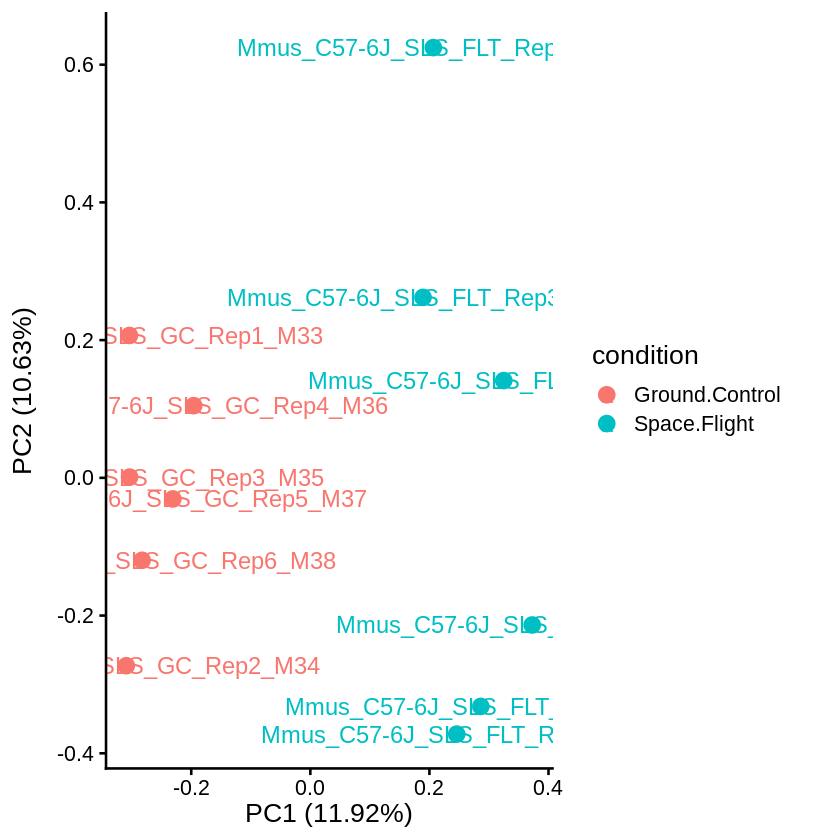

In [51]:
autoplot(PCA_raw, data=sampleTable, colour='condition',
         label=TRUE, label.size=5, size=4, alpha=1) + theme_classic(base_size = 16)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `autoplot()` - a function from the **ggplot2** package (typically used for visualizing PCA results). It automatically generates a plot based on the input object, which in this case is our PCA result.
  
  - `PCA_raw` - This is the variable holding the **PCA object** that we generated above, which contains the principal components of the log2 transformed raw transcript expression data. The first two principal components (PC1 and PC2) will be plotted on the x and y axes, respectively.

  - `data=sampleTable` - Specifies the sample metadata information storted in the `sampleTable` variable we created above.
  > This information will be used to color-code the samples based on which treatment group they belong to.

  - `colour='condition'` - This argument specifies that the points (samples) in the PCA plot will be colored according to the "condition" column in `sampleTable`.

  - `label=TRUE` - Instructions the `autoplot()` function to label each point using the sample names specified in the `sampleTable`.

  - `label.size=5` - Specifies the size of the _labels_ displayed on the PCA plot to be 5.

  - `size=4` - Specifies the size of the _points_ on the PCA plot to be 4.

  - `alpha=1` - Sets the _transparency_ of the points. This is a value between 0 and 1 such that `alpha=1` means the points are fully opaque, whereas lower values (e.g., `alpha=0.5`) would make the points semi-transparent.

- `+ theme_classic(base_size = 16)`
  - `theme_classic()` is a **ggplot2** theme function that gives the plot a classic, clean look (removing gridlines and simplifying axes).
  - `base_size=16` sets the _base font size_ of the plot, making all text (axis titles, labels, etc.) size 16 font.

</div>


Let's save your PCA plot, with all samples labeled, to your PCA directory defined in [Step 2b](#2b.-Set-up-Directory-Path-Variables-in-R) above using the `ggsave()` function.
> You can adjust the width, height, and dpi of the saved plot until you're satisfied with how the PCA plot looks.

In [52]:
ggsave(file.path(pca_dir, paste(GLDS, "_PCA_raw_wlabels.png", sep="")), width = 8.5, height = 6, dpi = 300)

The PCA plot with all samples labeled is a bit messy, don't you think?

Let's create another plot without the sample labels by indicating that the label is FALSE instead of TRUE, and save this plot again using `ggsave()`:

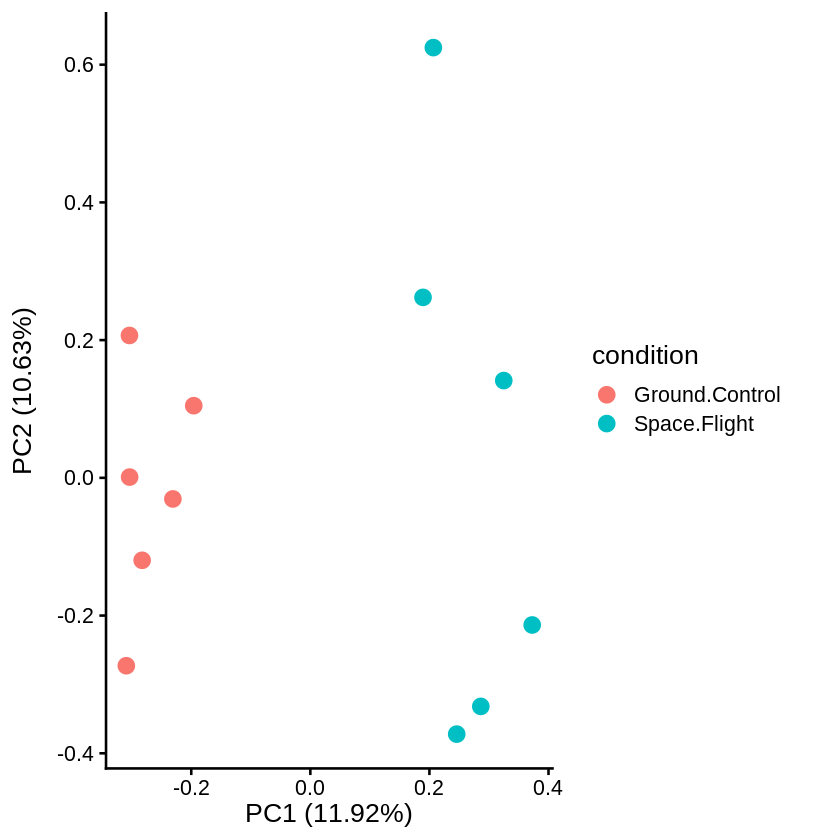

In [53]:
autoplot(PCA_raw, data=sampleTable, colour='condition',
         label=FALSE, label.size=5, size=4, alpha=1) + theme_classic(base_size = 16)

## Save your PCA plot without sample labels
ggsave(file.path(pca_dir, paste(GLDS, "_PCA_raw_nolabels.png", sep="")), width = 8.5, height = 6, dpi = 300)

<div class="alert alert-block alert-info">
<b>Note:</b><br>

Now that you know how to create plots with and without labels indicated, for the remaining PCA plots, we will only show the cleaner plots (without samples labeled). If you want to know which dot represents which sample, you are welcome to change the label back to TRUE in any of the plots we generate below.

</div>

**Take a look at the PCA plots we generated using the log2 transformed raw counts data and answer the following questions:**

1. Is there a pattern in how the samples are separating?

2. Would you expect the data points to separate like this based on their biological conditions? Why or why not?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

This will depend on your dataset, but samples will separate by experimental group if indeed the different treatments in each group impact transcript expression.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

If you anticipate that the different treatments impact transcript expression than you would expect the point (representing samples) to separate by their experimental groups.

</details>
</div>

<br>

---

**We are now ready to begin the DESeq2 analysis, which is composed of 3 steps.**

<br>

<a class="anchor" id="sizefactor"></a>
## 3b. DESeq2 Step 1: Size Factor Estimation

In this first step, called size factor estimation, the algorithm corrects for the sample-wise differences in read depth.

The `estimateSizeFactors()` function provided by DESeq2 performs RNA-seq read depth normalization using the median of ratios method on the DESeqDataSet Object, `dds` that we made in [step 2e](#2e.-Make-DESeqDataSet-Object) above.
> For additional information and training about the DESeq2 median of ratios method, visit [this HBC training](https://hbctraining.github.io/DGE_workshop/lessons/02_DGE_count_normalization.html).

<div class="alert alert-block alert-info">
<b>Median of ratios method</b><br>

1. A pseudo-reference sample is created for each transcript, which is equal to the genometric mean of that transcript's expression (count) across all samples.
2. For each transcript in a sample, the transcript expression for that sample is divided by the transcript expression for the pseudo-reference sample to create a ratio (sample/pseudo-reference) for each transcript in each sample.
3. The median value of all ratios for each sample is then extracted and used as the normalization factor (aka size factor) for that sample.
4. Lastly, each raw transcript count value in each sample is divided by that sample's normalization factor to generate the normalized expression (count) values for all transcripts for all samples.

</div>

In [54]:
dds_1 <- estimateSizeFactors(dds)

using 'avgTxLength' from assays(dds), correcting for library size



<br>

<a class="anchor" id="dispersions"></a>
## 3c. DESeq2 Step 2: Estimate Transcript Dispersions

Now that our count data are size-normalized, let's move on to the next step in the DESeq2 program: estimating transcript dispersions then shrinking the transcript-wise dispersion estimates toward the expected dispersion values.

The _dispersion_ of a transcript is a measure of the spread or variability of that transcript's expression in a dataset. We are interested in calculating the dispersion of each transcript to understand whether there is unexpected variability in our dataset, which may be due to technical artifacts, and then correct for it.

`DESeq2` measures dispersion as it relates the mean and variance of the data such that DESeq2 dispersion estimates are inversely related to the mean and directly related to variance. Thus, the dispersion is higher for small mean counts and lower for large mean counts.

The `estimateDispersions()` function provided by DESeq2 calculates the transcript-wise dispersions and then shrinks them in order to model the size-normalized counts for each transcript.
> For additional information and training on how DESeq2 estimates transcript dispersions and performs skrinkage, visit [this HBC training](https://hbctraining.github.io/DGE_workshop/lessons/04_DGE_DESeq2_analysis.html).

<div class="alert alert-block alert-info">
<b>Estimate transcript dispersions and perform skrinkage</b><br>

We first need to generate accurate estimates of within-group variation (i.e. variation between biological replicates of the same treatment group) for each transcript. However, since there are a small number of replicates per group (6 in our dataset), the estimates of variation for each transcript are often unreliable, especially for transcripts with smaller means (due to the large differences in dispersion for lower expressing transcripts). To address this issue, DESeq2 _shares information across transcripts_ to generate more accurate estimates of variation based on the mean expression level of the transcript.
  > Using this approach, referred to as "shrinkage", DESeq2 assumes that transcripts with similar expression levels have similar dispersion/variance.

1. **Estimate transcript-wise dispersion**: The dispersion for each transcript is estimated using maximum likelihood estimation (MLE). This means that the most likely estimate of dispersion is calculated for each transcript, given the transcript expression values (aka transcript counts) from all the replicates in each group.

2. **Generate estimation curve**: Next, the size-normalized count value of each transcript is plotted against the MLE of the dispersion for that transcript for all transcripts in all sample groups. The values on that plot are used to generate a curve that represents the estimate for the expected dispersion value for transcripts of a given expression strength (count value).

3. **Shrink transcript-wise dispersion estimates**: Finally, the transcript-wise dispersion estimates are shrunk towards the expected dispersion values predicted by the curve.
  > The strength of the shrinkage for each transcript depends on:
  > - how close the transcript dispersion is from the curve
  > - sample size (more samples = less shrinkage)

Transcripts with low dispersion estimates are shrunken towards the curve and transripts with dispersion estimates slightly above the curve are also shrunked towards the curve for better dispersion estimation of these transcripts. However, transcripts with extremely high dispersion values are not shrunken because these transcripts likely do not follow the DESeq2 modeling assumptions and have higher variability than the others for biological or technical reasons.
> Note: Shrinking these values toward the curve could result in false positives, which is why they are not shrunken. _These exceptionally high variability transcripts are shown as black dots surrounded by blue circles in the plot we will look at below._

**This shrinkage method is particular important to reduce false positives in the DTE analysis we will perform below.**

</div>


In [55]:
dds_1 <- estimateDispersions(dds_1)

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



<br>

**Visualize transcript-wise dispersion estimates**

Let's take a look at the relationship between the expression of each transcript and the transcript dispersion estimates we calculated above by plotting these values with the `plotDispEsts()` function:

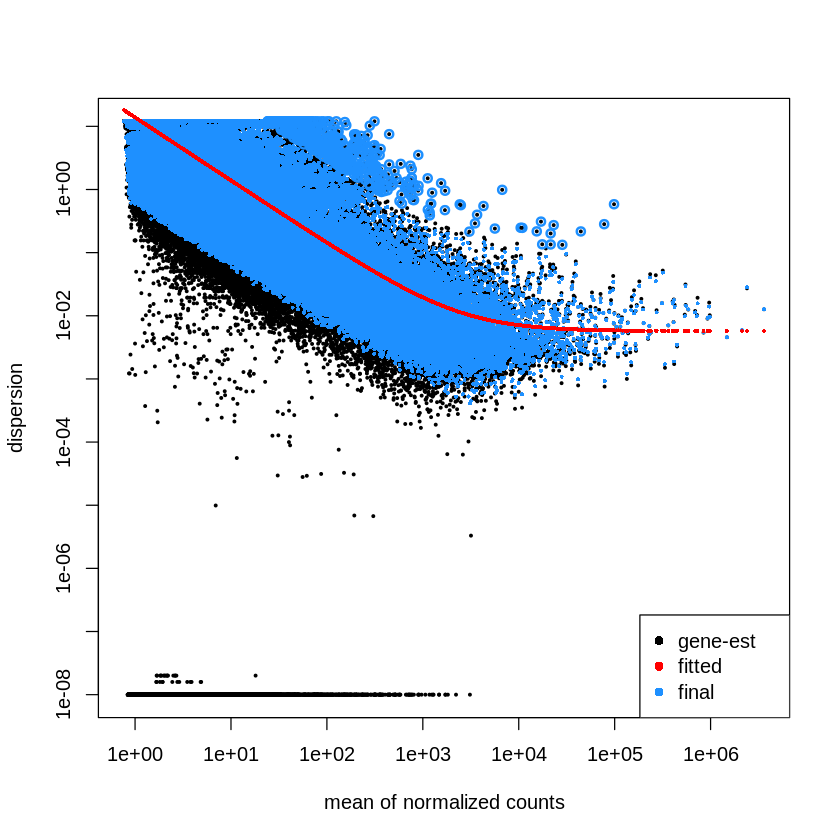

In [56]:
plotDispEsts(dds_1)

**Use the plot above to answer the following questions:**

1. What is the relationship between transcript dispersion and mean expression of a transcript? What does this tell you about RNA sequencing data?
2. How do the transcript expression data change before (black dots) and after (blue dots) fitting transcript dispersion estimates using the skrinkage method?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

As transcript expression (counts shown on the x-axis) increases, dispersion (on the y-axis) decreases.

This tells us that RNAseq data are noisy for low expressing transcripts.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The dispersion of the transcript expression data gets closer to the expected dispersion value for each transcript expression level after shrinkage.

</details>
</div>

<br>

---


<br>

<a class="anchor" id="wald"></a>
## 3d. DESeq2 Step 3: Hypothesis Testing with Wald Test

Finally, we are ready to proceed to the third and final step of the DESeq2 process, hypothesis testing. Hypothesis testing will tell us the probability of each transcript's expression being significantly different in one or more treatment groups.

We will perform our hypothesis testing using the Wald test, which is similar to a T-test. Recall from the "GL4U RNAseq Statistics Overview" lecture that the Wald test needs to know the type of data distribution to use to build a mathematical model suitable for hypothesis testing. RNAseq data most closely mimics a negative bionomial distribution, where the majority of transcripts have an expression value close to zero with some transcripts having higher expression values.

Therefore, we will use the `nbinomWaldTest()` function provided by DESeq2 to fit a negative binomial model to the transcript expression data and perform hypothesis testing using the Wald test.

<div class="alert alert-block alert-info">
<b>Negative binomial Wald test</b><br>

The DESeq2 `nbinomWaldTest()` function will calculate a Wald statistic for each transcript as shown below, along with a probability value (p-value) of the test. If the p-value is small, we reject the null hypothesis and state that there is evidence against the null (i.e. the transcript is differentially expressed).
> Note: The null hypothesis we are testing is that the transcript does not change expression significantly between the two groups.

$$
W = \frac{\hat{\beta}}{\text{SE}(\hat{\beta})}
$$

Where:
- $W$: The Wald statistic
- $\hat{\beta}$: The estimated log2 fold change (LFC) for the transcript between the two conditions (e.g. FLT and GC).
- $\text{SE}(\hat{\beta})$: The standard error of the LFC estimate calculated as follows:
  $$
  \text{SE}(\hat{\beta}) = \sqrt{\text{Var}(\hat{\beta})}
  $$
  Where:
  - $\text{Var}(\hat{\beta})$ is the estimated variance of the LFC.
  
</div>

**Multiple tests correction**

Recall from the "GL4U RNAseq Statistics Overview" lecture that the more transcripts we test, the more we inflate the false positive rate, which is know as the multiple testing problem.
> E.g. If we test 20,000 transcript for DE defined as p < 0.05, we would expect to find 1,000 transcripts by chance. If we found 2,000 DETs in total, about one half of our transcripts are likely false positives.

To reduce the number of false positives, in DESeq2, the p-values attained by the Wald test are corrected for multiple testing using the Benjamini and Hochberg (BH) method, by default, to generate an adjusted p-value for each transcript.
> **The adjusted p-values should be used to determine significant DETs.**

<div class="alert alert-block alert-info">
<b>BH method to adjust for FDR</b><br>

In DESeq2, the BH method for controlling the FDR is implemented by ranking the transcripts by p-value then multipying each ranked p-value by the ratio of the number of transcripts tested divided by the rank for that transcript, as shown below:

$$
\text{Adjusted p-value} = \text{p-value} \times \frac{m}{\text{rank}}
$$

Where:
- $m$: The total number of transcripts (i.e. total tests).
- $\text{rank}$: The rank of the transcript's p-value after sorting the transcripts by their p-values.

</div>

In [57]:
dds_1 <- nbinomWaldTest(dds_1)

Run the following command to store the normalized transcript counts as a matrix represented by the variable `normCounts`:

In [58]:
normCounts <- as.data.frame(counts(dds_1, normalized=TRUE))

**Answer the following questions:**

1. Is the Wald test the only type of hypothesis testing method we could have used here? (Hint: see the "Likelihood ratio test" section here: http://bioconductor.org/packages/devel/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)
   
2. Why did we choose the Wald test?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

No, the Wald test is not the only type of hypothesis testing method we could have used. The likelihood ratio test (LRT) is another option.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

We choose to use the Wald test because we are comparing two groups.

</details>
</div>

<br>

<div class="alert alert-block alert-info">
<b>Note:</b><br>

Although we do not calculate the likelihood ratio test (LRT) in this tutorial, since there are several RNAseq datasets on OSDR that contain more than 2 groups, the current GeneLab pipeline also runs the LRT to generate the F-statistic p-value, which is similar to the an ANOVA p-value, and the F-statistic adjusted p-value.
> _Only the F-statistic adjusted p-value is reported in the "LRT.p.value" column of the GeneLab differential_expression.csv file._

</div>

<br>


#### DESeq2 Likelihood ratio test (LRT)

Run the following code block to run the DESeq2 LRT on your data, save the output in the `dds_1_lrt` variable, then store the results of the analysis in the `res_1_lrt` variable:


In [59]:
dds_1_lrt <- DESeq(dds_1, test = "LRT", reduced = ~ 1)
res_1_lrt <- results(dds_1_lrt)

using pre-existing normalization factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



---

#### **PCA of normalized count data**

Now that we've normalized our count data, let's perform principal component analysis (PCA) of our normalized count data using the commands described in [step 3a](#3a.-PCA-of-Raw,-Unnormalized-Count-Data) above.

We'll start by log2 transforming our normalized count data then we'll calculate the principal components:

In [60]:
## Add 1 to every transcript count then log2 transform the normalized counts data ##
exp_norm <- log2(normCounts+1)

## Calculate the principal components of the normalized counts data ##
PCA_norm <- prcomp(t(exp_norm), scale = FALSE)

We're now ready to plot PC1 vs. PC2 (without labels) then save our plot with `ggsave()`:

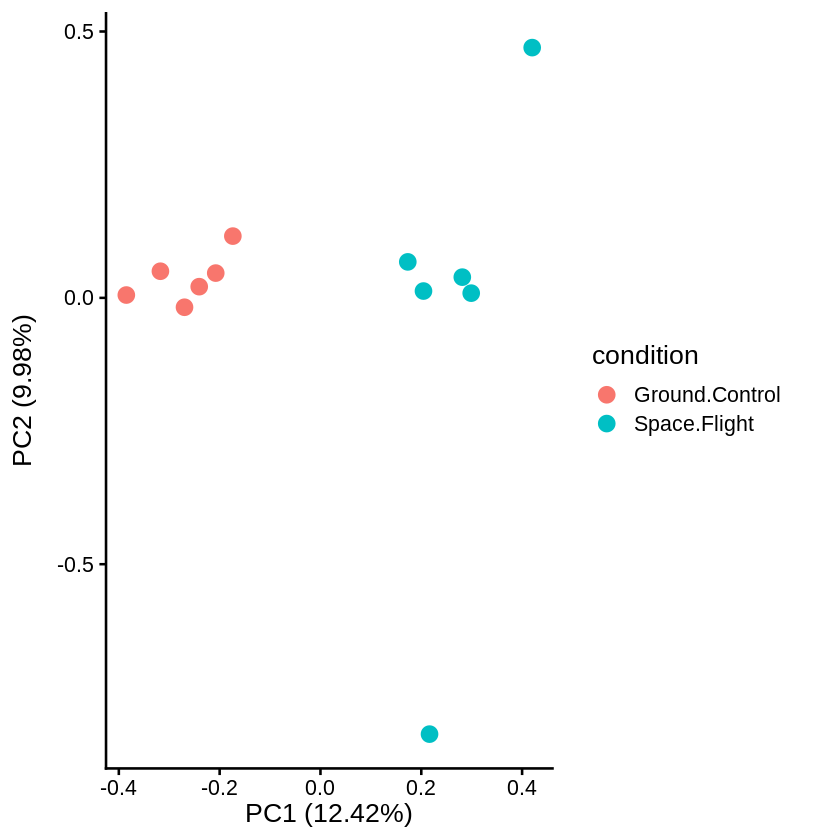

In [61]:
autoplot(PCA_norm, data=sampleTable, colour='condition',
         label=FALSE, label.size=5, size=4, alpha=1) + theme_classic(base_size = 16)

## Save your PCA plot without sample labels
ggsave(file.path(pca_dir, paste(GLDS, "_PCA_norm_nolabels.png", sep="")), width = 8.5, height = 6, dpi = 300)

**Look at the PCA plots before and after normalization, and answer the following questions:**

1. Is the percent of variance explained by PC2 more or less after normalization? Does that tell you anything about what was contributing to the differences in PC2?
   
2. How has the within-group variation changed? Why do you think that is?
   
3. How has the percent of variance explained by PC1 changed? What does this mean?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

This will depend on the dataset you're analyzing. If the raw count data showed samples separating by treatment group in PC1 and PC2 likely accounted for technical differences between samples, then the percent of variance explained by PC2 would be less after normalization.

This would suggest that some of the differences among samples observed in the raw count data were driven by technical differences between samples that have been corrected for upon normalization.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

This will depend on the dataset you're analyzing. If the raw count data showed samples separating by treatment group in PC1 and PC2 likely accounted for technical differences between samples, then the within group variation will now be smaller, i.e. the samples within each treatment group are closer together than they were using the raw count data.

This would suggest that some of the differences among samples within the same group were due to technical artifacts.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

This will depend on the dataset you're analyzing. If the raw count data showed samples separating by treatment group in PC1 and PC2 likely accounted for technical differences between samples, then the percent of variance explained by PC1 would have increased.

This would suggest that the differences explained by PC1, which appears to represent the biological signal (i.e. the differences between the treatment groups) became stronger after normalizing for technical differences.

</details>
</div>


<br>

---

**Challenge:** Use the next few code blocks to 1) list the number of PCs after normalization and 2) recreate the PCA plot but adjust these parameters: label.size, size, alpha (must be between 0 and 1). How does your plot change?
> Hint: 1) Use the `summary()` function we used in step 3a. 2) Fist copy the `autoplot()` command from the previous code block then change the parameters.

In [67]:
summary(PCA_norm)

Importance of components:
                            PC1      PC2      PC3      PC4      PC5      PC6
Standard deviation     106.8729 95.78597 94.32568 92.43025 91.01484 89.51536
Proportion of Variance   0.1242  0.09976  0.09674  0.09289  0.09007  0.08713
Cumulative Proportion    0.1242  0.22395  0.32069  0.41358  0.50365  0.59077
                            PC7      PC8      PC9     PC10     PC11      PC12
Standard deviation     89.04587 87.91573 86.53112 85.95009 84.28245 1.925e-13
Proportion of Variance  0.08621  0.08404  0.08141  0.08032  0.07724 0.000e+00
Cumulative Proportion   0.67699  0.76103  0.84244  0.92276  1.00000 1.000e+00

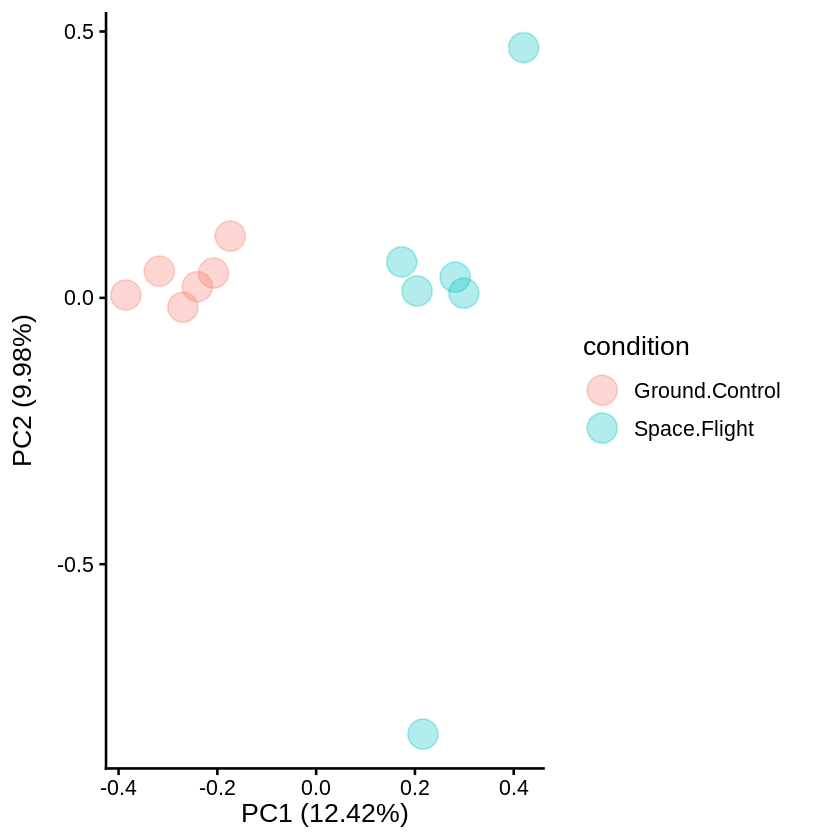

In [68]:
autoplot(PCA_norm, data=sampleTable, colour='condition',
         label=FALSE, label.size=5, size=8, alpha=0.3) + theme_classic(base_size = 16)

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

```R
autoplot(PCA_norm, data=sampleTable, colour='condition',
         label=FALSE, label.size=5, size=8, alpha=0.3) + theme_classic(base_size = 16)
```

The size of the dots changed and became more transparent.

</details>
</div>

<br>

---

<a class="anchor" id="dte"></a>
# 4. DTE Analysis
> **Required runtime:** R

The results of the DESeq2 analysis we performed in [step 3](#3.-DESeq2-Analysis) are currently stored in the `dds_1` object. In the next steps, we will create a differential transcript expression (DTE) output table and use the `results()` function to extract the DESeq2 results and add them to the table. We will start with our normalized counts table generated at the end of [Step 3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test) above and add pair-wise comparison columns containing the group 1 vs group 2 statistical data from the Wald tests performed in [Step 3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test). We will also perform calculations to generate columns containing all samples as well as group means and standard deviations and complete the table by adding transcript annotations.

<a class="anchor" id="calculations"></a>
## 4a. Perform Data Calculations and Create DTE Output Table

**Create DTE output table**

We'll start the DTE output table, held in the variable `DTE_output_table`, by adding the normalized transcript count data from each sample created in [step 3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test):  

In [69]:
DTE_output_table <- normCounts

Take a look at the first 6 rows of our initial DTE table.

In [70]:
options(repr.matrix.max.cols=150)
head(DTE_output_table)

,Mmus_C57-6J_SLS_GC_Rep1_M33,Mmus_C57-6J_SLS_GC_Rep2_M34,Mmus_C57-6J_SLS_GC_Rep3_M35,Mmus_C57-6J_SLS_GC_Rep4_M36,Mmus_C57-6J_SLS_GC_Rep5_M37,Mmus_C57-6J_SLS_GC_Rep6_M38,Mmus_C57-6J_SLS_FLT_Rep1_M23,Mmus_C57-6J_SLS_FLT_Rep2_M24,Mmus_C57-6J_SLS_FLT_Rep3_M25,Mmus_C57-6J_SLS_FLT_Rep4_M26,Mmus_C57-6J_SLS_FLT_Rep5_M27,Mmus_C57-6J_SLS_FLT_Rep6_M28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000000001,1015.956224,932.673811,971.904103,854.730640,864.43699,917.82032,1019.505537,841.421791,812.979616,841.270921,894.182563,849.867514
ENSMUST00000000028,69.993442,87.178973,109.112368,81.851298,93.92000,83.51016,86.819094,114.377937,56.461401,120.864548,111.286825,121.418730
ENSMUST00000096990,45.544600,23.583020,9.920648,17.537203,19.57316,34.17714,11.732567,8.338201,20.440626,4.838259,41.846838,0.000000
ENSMUST00000115585,6.754389,9.209874,2.708226,5.840051,11.77160,11.98333,7.040625,21.407216,7.780568,7.783223,8.383129,4.858796
ENSMUST00000132294,130.778954,108.609393,132.621679,88.629741,115.57959,150.42351,100.905667,89.286985,72.981239,114.405269,69.506833,66.792659
ENSMUST00000136359,96242.098810,86133.771422,92533.877510,89332.086387,84851.11773,96653.70409,64297.272620,63065.114344,67069.925710,70898.333589,47936.604713,54734.595496


<div class="alert alert-block alert-info">
<b>Note:</b><br>

The DTE output table currently has 1 column for each sample, and the rows are transcripts (shown here as ENSEMBL or TAIR  IDs for animals or plants, respectively).

</div>


**Add pairwise comparison columns**

Next we'll iterate through the results of the Wald tests to generate pairwise comparison columns for each contrast listed in our `contrasts` table.

Let's first take a look at the contrasts we set up at the end of [step 2c](#2c.-Import-and-Format-Sample-Metadata-in-R):

In [71]:
contrasts

(Ground Control)v(Space Flight),(Space Flight)v(Ground Control)
Ground.Control,Space.Flight
Space.Flight,Ground.Control


We want to iterate through each contrast shown above and report the log2 fold change, Wald statistic, p-value, and adjusted p-value from the Wald Tests we performed in [Step 3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test).

In [72]:
for (i in 1:dim(contrasts)[2]){
   res_1 <- results(dds_1, contrast=c("condition",contrasts[1,i],contrasts[2,i]))
	res_1 <- as.data.frame(res_1@listData)[,c(2,4,5,6)]
	colnames(res_1) <-c(paste0("Log2fc_",colnames(contrasts)[i]),
                        paste0("Stat_",colnames(contrasts)[i]),
                        paste0("P.value_",colnames(contrasts)[i]),
                        paste0("Adj.p.value_",colnames(contrasts)[i]))
	DTE_output_table <- cbind(DTE_output_table,res_1)
}

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `for (i in 1:dim(contrasts)[2]){}`:  
  - This is a _for loop_ that iterates over each column of the `contrasts` matrix.
  - `dim(contrasts)[2]` returns the number of columns in the `contrasts` matrix, meaning the loop will iterate from 1 to the total number of contrasts.
  - **`i`** represents the index of the current contrast column being processed.

- `res_1 <- results(dds_1, contrast=c("condition", contrasts[1,i], contrasts[2,i]))`:  
  - This line uses the `results()` function from DESeq2 to obtain the differential expression results for a specific contrast.
  - `dds_1`: The DESeqDataSet object that contains the DESeq2 results.
  - `contrast=c("condition", contrasts[1,i], contrasts[2,i])`: This specifies the contrast for the condition being tested. It extracts the values from the `contrasts` matrix for the current iteration, where:
    - `contrasts[1,i]`: The first level of the condition being compared.
    - `contrasts[2,i]`: The second level of the condition being compared.
  - The `results()` function returns an object containing p-values, log2 fold changes, and other statistical results that is stored in the `res_1` variable.

- `res_1 <- as.data.frame(res_1@listData)[,c(2,4,5,6)]`:  
  - Converts the `results` object (which is an S4 object) to a _data frame_ by accessing its `listData` slot.
  - `[,c(2,4,5,6)]`: Selects specific columns from the `listData`, which are:
    - Column 2: Log2 fold change (log2FC).
    - Column 4: Wald statistic (Stat).
    - Column 5: Raw p-value (P.value).
    - Column 6: Adjusted p-value (Adj.p.value).

- `colnames(res_1) <- c(paste0("Log2fc_", colnames(contrasts)[i]), paste0("Stat_", colnames(contrasts)[i]), paste0("P.value_", colnames(contrasts)[i]), paste0("Adj.p.value_", colnames(contrasts)[i]))`:  
  - Renames the columns in `res_1` using the `paste0()` function, which concatenates strings.
  - The column names for each result are customized based on the contrast currently being evaluated (`colnames(contrasts)[i]`). For example:
    - `"Log2fc_"` will be followed by the name of the contrast for that column.
    - `"Stat_"`, `"P.value_"`, and `"Adj.p.value_"` follow the same pattern for the corresponding statistics.

- `DTE_output_table <- cbind(DTE_output_table, res_1)`:  
  - `cbind()` (column bind) appends the results (`res_1`) as new columns to the existing DTE output table (`DTE_output_table`).

> Note: The loop will iteratively add new sets of results for each contrast, appending them as additional columns to the `DTE_output_table`.

</div>

<br>

**Add all mean and standard deviation columns**

For each transcript, we will calculate the mean expression and standard deviation across all samples and add these calculations to the DTE output table.

In [73]:
DTE_output_table$All.mean <- rowMeans(normCounts, na.rm = TRUE, dims = 1)
DTE_output_table$All.stdev <- rowSds(as.matrix(normCounts), na.rm = TRUE, dims = 1)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `DTE_output_table$All.mean <- rowMeans(normCounts, na.rm = TRUE, dims = 1)`:
  - `DTE_output_table$All.mean`: This creates a new column in the `DTE_output_table` data frame called `All.mean`, which will store the mean of each row (transcript) across all samples.
  - `rowMeans(normCounts, na.rm = TRUE, dims = 1)`:
    - `rowMeans()`: A base R function that calculates the _mean_ for each row in a matrix or data frame.
    - `normCounts`: This is the matrix that contains the normalized counts for each transcript (rows) across all samples (columns).
    - `na.rm = TRUE`: Specifies that missing values (`NA`) should be removed before calculating the means.
      > _Note: If this is set to `FALSE`, the presence of `NA` values would cause the mean to return `NA`._
    - `dims = 1`: This specifies that the function should calculate means along rows (transcripts), not columns.
      > _Note: In `rowMeans()`, `dims = 1` is the default and ensures the function operates row-wise._

- `DTE_output_table$All.stdev <- rowSds(as.matrix(normCounts), na.rm = TRUE, dims = 1)`:
  - `DTE_output_table$All.stdev`: This creates a new column in the `DTE_output_table` data frame called `All.stdev`, which will store the standard deviation of each row (transcript) across all samples.
  - `rowSds(as.matrix(normCounts), na.rm = TRUE, dims = 1)`:
    - `rowSds()`: A function from the _matrixStats_ package that calculates the _standard deviation_ for each row in a matrix.
    - `as.matrix(normCounts)`: Converts the `normCounts` object into a matrix (if it is not already a matrix) because the `rowSds()` function requires a matrix as input.
    - `na.rm = TRUE`: Ensures that any missing values (`NA`) are removed before calculating the standard deviation.
    - `dims = 1`: This specifies that the function should calculate standard deviations along rows (transcripts), which is the default for `rowSds()`.

</div>

<br>

**Challenge:** Use the code block below to look at the first 6 rows of the DTE output table now.

> Hint: Use the head() function we used at the beginning of this step (4a).

In [74]:
head(DTE_output_table)

,Mmus_C57-6J_SLS_GC_Rep1_M33,Mmus_C57-6J_SLS_GC_Rep2_M34,Mmus_C57-6J_SLS_GC_Rep3_M35,Mmus_C57-6J_SLS_GC_Rep4_M36,Mmus_C57-6J_SLS_GC_Rep5_M37,Mmus_C57-6J_SLS_GC_Rep6_M38,Mmus_C57-6J_SLS_FLT_Rep1_M23,Mmus_C57-6J_SLS_FLT_Rep2_M24,Mmus_C57-6J_SLS_FLT_Rep3_M25,Mmus_C57-6J_SLS_FLT_Rep4_M26,Mmus_C57-6J_SLS_FLT_Rep5_M27,Mmus_C57-6J_SLS_FLT_Rep6_M28,Log2fc_(Ground Control)v(Space Flight),Stat_(Ground Control)v(Space Flight),P.value_(Ground Control)v(Space Flight),Adj.p.value_(Ground Control)v(Space Flight),Log2fc_(Space Flight)v(Ground Control),Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000000001,1015.956224,932.673811,971.904103,854.730640,864.43699,917.82032,1019.505537,841.421791,812.979616,841.270921,894.182563,849.867514,0.08081968,1.1911563,2.335922e-01,5.657010e-01,-0.08081968,-1.1911563,2.335922e-01,5.657010e-01,901.395836,70.436039
ENSMUST00000000028,69.993442,87.178973,109.112368,81.851298,93.92000,83.51016,86.819094,114.377937,56.461401,120.864548,111.286825,121.418730,-0.21703311,-1.0834490,2.786092e-01,6.209253e-01,0.21703311,1.0834490,2.786092e-01,6.209253e-01,94.732898,20.781789
ENSMUST00000096990,45.544600,23.583020,9.920648,17.537203,19.57316,34.17714,11.732567,8.338201,20.440626,4.838259,41.846838,0.000000,0.77292417,1.0827868,2.789031e-01,6.211576e-01,-0.77292417,-1.0827868,2.789031e-01,6.211576e-01,19.794355,14.413990
ENSMUST00000115585,6.754389,9.209874,2.708226,5.840051,11.77160,11.98333,7.040625,21.407216,7.780568,7.783223,8.383129,4.858796,-0.24564096,-0.4975936,6.187705e-01,8.720697e-01,0.24564096,0.4975936,6.187705e-01,8.720697e-01,8.793419,4.757809
ENSMUST00000132294,130.778954,108.609393,132.621679,88.629741,115.57959,150.42351,100.905667,89.286985,72.981239,114.405269,69.506833,66.792659,0.50154064,2.7450683,6.049830e-03,4.714046e-02,-0.50154064,-2.7450683,6.049830e-03,4.714046e-02,103.376793,26.881927
ENSMUST00000136359,96242.098810,86133.771422,92533.877510,89332.086387,84851.11773,96653.70409,64297.272620,63065.114344,67069.925710,70898.333589,47936.604713,54734.595496,0.56852733,6.4986765,8.102967e-11,4.632841e-09,-0.56852733,-6.4986765,8.102967e-11,4.632841e-09,76145.708535,16836.168945


<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

```R
head(DTE_output_table)
```

</details>
</div>

<br>

**Look at the DTE output table now and answer the following questions:**
1. How many columns have been added?
  
2. What is the average expression of the first transcript listed across all samples?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of columns that have been added is equal to 4 * [Number of contrasts] + 2. 4 because there are 4 results columns (log2 fold change, Wald statistic, p-value, and adjusted p-value) added per contrast plus the `All.mean` and `All.stdev` columns we just added.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The average expression of the first transcript listed will be the value in the `All.mean` column associated with the first transcript listed.

</details>
</div>

<br>

**Add the DESeq2 LRT value:**

If you calculated the DESeq2 LRT value for these data in [step 3d](#DESeq2-Likelihood-ratio-test-(LRT)) above, you can add the F statistic p-value (similar to ANOVA p-value) generated from the LRT to the DTE output table by running the following command:


In [75]:
DTE_output_table$LRT.p.value <- res_1_lrt@listData$padj

<br>

**Add group mean and standard deviation columns**

Next, we'll calculate the mean expression for each transcript across samples within each group, and add group means to the `DTE_output_table`.
> Note: This can take several minutes depending on how many sample groups are in your dataset.

In [76]:
tcounts <- as.data.frame(t(normCounts))
tcounts$group <- group
group_means <- as.data.frame(t(aggregate(. ~ group,data = tcounts,mean)))
group_means <- group_means[-c(1),]
colnames(group_means) <- paste0("Group.Mean_",levels(factor(names(group))))

DTE_output_table <- cbind(DTE_output_table,group_means)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `tcounts <- as.data.frame(t(normCounts))`:  
  - `t(normCounts)`: Transposes the `normCounts` matrix so that rows become columns and columns become rows.
    > - _Before transposing_: Rows represent transcripts and columns represent samples.
    > - _After transposing_: Rows now represent samples, and columns represent transcripts.
  - `as.data.frame()`: Converts the transposed matrix into a data frame called `tcounts`, so it can be manipulated more easily in subsequent steps.

- `tcounts$group <- group`:  
  - Adds a new column titled "group" to the `tcounts` data frame, that specifies which group each sample belongs to using the `group` variable created in [step 1b](#1b.-Import-the-Data) above.

- `group_means <- as.data.frame(t(aggregate(. ~ group, data = tcounts, mean)))`:  
  - `aggregate(. ~ group, data = tcounts, mean)`: Calculates the _mean_ of each transcript for each group in `tcounts`:
    - `~ group`: Specifies that the data should be grouped by the `group` variable.
    - `.`: Refers to all other columns (transcripts) in `tcounts`.
    - `mean`: Computes the mean of each transcript for each group.
  - `t()`: Transposes the resulting data frame (so that the group means for each transcript are in columns, with rows representing transcripts).
  - `as.data.frame()`: Converts the transposed matrix into a data frame called `group_means`.

- `group_means <- group_means[-c(1),]`:  
  - Removes the first row from the `group_means` data frame, which is the `group` row created by the `aggregate()` function (which serves as metadata rather than transcript data).
  - `[-c(1),]`: This removes the first row, keeping the remaining rows (transcript expression means for each group).

- `colnames(group_means) <- paste0("Group.Mean_", levels(factor(names(group))))`:  
  - Renames the columns in `group_means` to reflect the group each mean belongs to:
    - `paste0("Group.Mean_", levels(factor(names(group)))`: Creates new column names by concatenating `"Group.Mean_"` with the group names.
    - `levels(factor(names(group)))`: Extracts the group names from the `group` variable.


- `DTE_output_table <- cbind(DTE_output_table, group_means)`:  
  - `cbind()`: Column-binds the `group_means` data frame to the `DTE_output_table`, adding the group-wise transcript means as new columns in the DTE output table.

</div>

<br>

Now, we'll calculate the standard deviation for each transcript across samples within each group, and add group standard deviations to the `DTE_output_table`.

In [78]:
group_stdev <- as.data.frame(t(aggregate(. ~ group,data = tcounts,sd)))
group_stdev <- group_stdev[-c(1),]
colnames(group_stdev) <- paste0("Group.Stdev_",levels(factor(names(group))))

DTE_output_table <- cbind(DTE_output_table,group_stdev)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `group_stdev <- as.data.frame(t(aggregate(. ~ group, data = tcounts, sd)))`:  
  - This command is similar to the one above, but instead of calculating the mean, it calculates the _standard deviation_ (`sd`) of each transcript for each group.
  - `aggregate(. ~ group, data = tcounts, sd)`: Aggregates the data by `group` and calculates the standard deviation for each transcript.
  - `as.data.frame(t())`: Transposes and converts the result into a data frame called `group_stdev`.

- `group_stdev <- group_stdev[-c(1),]`:  
  - Removes the first row of the `group_stdev` data frame, similar to how it was done for `group_means`, since the first row is the metadata for `group`.

- `colnames(group_stdev) <- paste0("Group.Stdev_", levels(factor(names(group))))`:  
  - Renames the columns in `group_stdev` to reflect the group each standard deviation belongs to:
    - `paste0("Group.Stdev_", levels(factor(names(group)))`: Creates new column names by concatenating `"Group.Stdev_"` with the group names.


- `DTE_output_table <- cbind(DTE_output_table, group_stdev)`:  
  - `cbind()`: Similarly, column-binds the `group_stdev` data frame to the `DTE_output_table`, adding the group-wise transcript standard deviations as new columns.

</div>

<br>

**Use the code block below to look at the first few rows of the DTE output table now and answer the following question:**

In [79]:
head(DTE_output_table)

,Mmus_C57-6J_SLS_GC_Rep1_M33,Mmus_C57-6J_SLS_GC_Rep2_M34,Mmus_C57-6J_SLS_GC_Rep3_M35,Mmus_C57-6J_SLS_GC_Rep4_M36,Mmus_C57-6J_SLS_GC_Rep5_M37,Mmus_C57-6J_SLS_GC_Rep6_M38,Mmus_C57-6J_SLS_FLT_Rep1_M23,Mmus_C57-6J_SLS_FLT_Rep2_M24,Mmus_C57-6J_SLS_FLT_Rep3_M25,Mmus_C57-6J_SLS_FLT_Rep4_M26,Mmus_C57-6J_SLS_FLT_Rep5_M27,Mmus_C57-6J_SLS_FLT_Rep6_M28,Log2fc_(Ground Control)v(Space Flight),Stat_(Ground Control)v(Space Flight),P.value_(Ground Control)v(Space Flight),Adj.p.value_(Ground Control)v(Space Flight),Log2fc_(Space Flight)v(Ground Control),Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Mean_(Space Flight)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSMUST00000000001,1015.956224,932.673811,971.904103,854.730640,864.43699,917.82032,1019.505537,841.421791,812.979616,841.270921,894.182563,849.867514,0.08081968,1.1911563,2.335922e-01,5.657010e-01,-0.08081968,-1.1911563,2.335922e-01,5.657010e-01,901.395836,70.436039,5.615812e-01,926.2537,876.5380
ENSMUST00000000028,69.993442,87.178973,109.112368,81.851298,93.92000,83.51016,86.819094,114.377937,56.461401,120.864548,111.286825,121.418730,-0.21703311,-1.0834490,2.786092e-01,6.209253e-01,0.21703311,1.0834490,2.786092e-01,6.209253e-01,94.732898,20.781789,6.157388e-01,87.59437,101.87142
ENSMUST00000096990,45.544600,23.583020,9.920648,17.537203,19.57316,34.17714,11.732567,8.338201,20.440626,4.838259,41.846838,0.000000,0.77292417,1.0827868,2.789031e-01,6.211576e-01,-0.77292417,-1.0827868,2.789031e-01,6.211576e-01,19.794355,14.413990,6.170417e-01,25.05596,14.53275
ENSMUST00000115585,6.754389,9.209874,2.708226,5.840051,11.77160,11.98333,7.040625,21.407216,7.780568,7.783223,8.383129,4.858796,-0.24564096,-0.4975936,6.187705e-01,8.720697e-01,0.24564096,0.4975936,6.187705e-01,8.720697e-01,8.793419,4.757809,8.687551e-01,8.044578,9.542259
ENSMUST00000132294,130.778954,108.609393,132.621679,88.629741,115.57959,150.42351,100.905667,89.286985,72.981239,114.405269,69.506833,66.792659,0.50154064,2.7450683,6.049830e-03,4.714046e-02,-0.50154064,-2.7450683,6.049830e-03,4.714046e-02,103.376793,26.881927,4.668263e-02,121.10714,85.64644
ENSMUST00000136359,96242.098810,86133.771422,92533.877510,89332.086387,84851.11773,96653.70409,64297.272620,63065.114344,67069.925710,70898.333589,47936.604713,54734.595496,0.56852733,6.4986765,8.102967e-11,4.632841e-09,-0.56852733,-6.4986765,8.102967e-11,4.632841e-09,76145.708535,16836.168945,5.275918e-09,90957.78,61333.64


1. How many columns have been added?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The number of columns that have been added to the DTE table is equal to 2 * [Number of groups], one new column for the group mean and one for the standard deviation per group.

</details>
</div>

<br>

---

<a class="anchor" id="annotations"></a>
## 4b. Add Transcript Annotations

Looking at the first column of our DTE table above, you'll notice that the transcripts are listed as ENSEMBL or TAIR transcript IDs (for animal or plant datasets, respectively), which doesn't really mean much to anyone unless you have a list of which transcript each ENSEMBL or TAIR ID represents. Since transcript names can be long, it may also be useful to know which transcript symbol corresponds to each ENSEMBL or TAIR ID. Furthermore, depending on what downstream analyses you want to run, having a list of IDs from other databases such as RefSeq, Entrez, and/or GOSLIM may be required. Therefore, in this step, we will run a series of commands to add columns to our DTE output table containing other transcript identifiers that correspond to the respective ENSEMBL or TAIR ID.

**Define the organism**

We will start by defining the organism used in the study with the respecitve identifiers found in the various databases we will extract annotations from:

<div class="alert alert-block alert-info">
<b>Note:</b><br>

- The `organism` identifier specified must match the "Short Name" for that organism in the [PANTHER database](https://www.pantherdb.org/panther/summaryStats.jsp).
  > In this JN we use [PANTHER database version 18.0](https://archive.pantherdb.usc.edu/panther/summaryStats.jsp)
- The `ann.dbi` identifier specified must match the [Bioconductor annotation package](https://www.bioconductor.org/packages/release/BiocViews.html#___AnnotationData) for the organism. Be sure to use the package with the "Bioconductor Package Maintainer" listed in the "Maintainer" column.
  > In this JN we use [Bioconductor version 3.19 AnnotationData Packages](https://bioconductor.org/packages/3.19/data/annotation/)
- The `taxonid` identifier specified must match the NCBI taxonomy ID for the organism, which can be searched for in the [NCBI taxonomy browser](https://www.ncbi.nlm.nih.gov/taxonomy/).

</div>


In [80]:
organism <- "MOUSE"
ann.dbi <- "org.Mm.eg.db"
taxonid <- 10090

**Load libraries for transcript annotations**
Import R libraries that will allow us to add transcript annotations to the DTE output table:

In [81]:
library(org.Mm.eg.db)
library(STRINGdb)
library(PANTHER.db)

Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select


The following object is masked from ‘package:dplyr’:

    select




Loading required package: AnnotationHub

Loading required package: BiocFileCache

Loading required package: dbplyr


Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql



Attaching package: ‘AnnotationHub’


The following object is masked from ‘package:Biobase’:

    cache


Loading required package: RSQLite

PANTHER.db version 1.0.12



**Create annotation table**

We'll begin building an annotation table for the organism used in this study (mouse, in this example) by pulling in annotations found in the `org.Mm.eg.db` Bioconductor annotation package:
> _Note: These annotations are added using the ENSEMBL mouse transcript IDs as the keytype._

In [82]:
keytype <- "ENSEMBLTRANS"
annot <- data.frame(rownames(DTE_output_table), stringsAsFactors = FALSE)
colnames(annot)[1]<- "ENSEMBLTRANS"
if ("SYMBOL" %in% columns(eval(parse(text = ann.dbi),env=.GlobalEnv))){
	annot$SYMBOL<-mapIds(eval(parse(text = ann.dbi),env=.GlobalEnv),
                         keys = rownames(DTE_output_table),
                         keytype = keytype,
                         column = "SYMBOL",
                         multiVals = "first")
}
if ("GENENAME" %in% columns(eval(parse(text = ann.dbi),env=.GlobalEnv))){
        annot$GENENAME<-mapIds(eval(parse(text = ann.dbi),env=.GlobalEnv),
                               keys = rownames(DTE_output_table),
                               keytype = keytype,
                               column = "GENENAME",
                               multiVals = "first")
}
if ("REFSEQ" %in% columns(eval(parse(text = ann.dbi),env=.GlobalEnv))){
        annot$REFSEQ<-mapIds(eval(parse(text = ann.dbi),env=.GlobalEnv),
                             keys = rownames(DTE_output_table),
                             keytype = keytype,
                             column = "REFSEQ",
                             multiVals = "first")
}
if ("ENTREZID" %in% columns(eval(parse(text = ann.dbi),env=.GlobalEnv))){
        annot$ENTREZID<-mapIds(eval(parse(text = ann.dbi),env=.GlobalEnv),
                               keys = rownames(DTE_output_table),
                               keytype = keytype,
                               column = "ENTREZID",
                               multiVals = "first")
}

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `keytype <- "ENSEMBLTRANS"`:
  - `keytype`: A variable that stores the type of transcript identifier being used, which in this case is `"ENSEMBLTRANS"`. This defines how transcript identifiers will be looked up in the annotation database.
  - `"ENSEMBLTRANS"`: Refers to Ensembl transcript IDs (e.g., `ENSMUST00000000001`), which are typically used as the main key for transcript annotation mapping.

- `annot <- data.frame(rownames(DTE_output_table), stringsAsFactors = FALSE)`:
  - `rownames(DTE_output_table)`: Retrieves the row names of `DTE_output_table`, which are the transcript IDs (in this case, Ensembl IDs).
  - `data.frame()`: Creates a new data frame called `annot` using the row names of `DTE_output_table` as the first column. The option `stringsAsFactors = FALSE` ensures that the transcript identifiers are treated as strings (characters) rather than factors.
  - `annot`: This will be the annotation table where we will map additional transcript annotations, like transcript symbols.

- `colnames(annot)[1] <- "ENSEMBL"`:  
  - `colnames(annot)[1]`: Refers to the name of the first column in the `annot` data frame (currently containing Ensembl IDs).
  - `<- "ENSEMBL"`: Sets the name of this column to `"ENSEMBL"`. This makes the column name `"ENSEMBL"` in the `annot` data frame.

- `if ("SYMBOL" %in% columns(eval(parse(text = ann.dbi), env = .GlobalEnv))){}`:  
  - `"SYMBOL" %in% columns(...)`: Checks whether the `"SYMBOL"` column exists in the annotation database. `"SYMBOL"` refers to the transcript symbol (e.g., `Gnai3`).
  - `eval(parse(text = ann.dbi), env = .GlobalEnv)`: This evaluates the variable `ann.dbi` as an object within the global environment (`.GlobalEnv`).
    > _Note: `ann.dbi` holds the string "org.Mm.eg.db", which refers to the Bioconductor annotation database object for mouse._
  - `columns()`: Retrieves the available columns in the annotation database, including different types of transcript identifiers (like `ENSEMBL`, `SYMBOL`, etc.).

- `annot$SYMBOL <- mapIds(eval(parse(text = ann.dbi), env = .GlobalEnv), keys = rownames(DTE_output_table), keytype = keytype, column = "SYMBOL", multiVals = "first")`:  
  - `annot$SYMBOL`: Creates a new column called `SYMBOL` in the `annot` data frame, which will store transcript symbols corresponding to each Ensembl transcript ID.
  - `mapIds()`: This function is used to map identifiers (e.g., Ensembl transcript IDs) to another identifier type (e.g., transcript symbols). It performs the actual mapping based on the specified database and parameters:
    - `eval(parse(text = ann.dbi), env = .GlobalEnv)`: Evaluates `ann.dbi` as the annotation database object from which transcript IDs will be mapped.
    - `keys = rownames(DTE_output_table)`: The Ensembl transcript IDs from `DTE_output_table` are provided as the keys to be mapped.
    - `keytype = keytype`: Specifies that the transcript IDs are of type `"ENSEMBL"` (as defined by the `keytype` variable).
    - `column = "SYMBOL"`: Specifies that we want to retrieve the _transcript symbols_ (`SYMBOL`) corresponding to each Ensembl transcript ID.
    - `multiVals = "first"`: If a gene has multiple symbols, this ensures that only the first symbol is returned for each transcript (to avoid returning multiple values for a single key).

> _Note: These same commands are used to extract "GENENAME", "REFSEQ", and "ENTREZID" IDs for each transcript and add them as additional columns in the `annot` annotation table._

</div>

<br>

**Challenge:** Use the following code block to view the first 6 rows of our Transcript Annotation table, `annot`.
> Hint: Use the `head()` function.

In [83]:
head(annot)

,ENSEMBLTRANS,SYMBOL,GENENAME,REFSEQ,ENTREZID
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENSMUST00000000001,Gnai3,G protein subunit alpha i3,NM_010306,14679
2,ENSMUST00000000028,NA,NA,NA,NA
3,ENSMUST00000096990,NA,NA,NA,NA
4,ENSMUST00000115585,NA,NA,NA,NA
5,ENSMUST00000132294,NA,NA,NA,NA
6,ENSMUST00000136359,NA,NA,NA,NA


**Add STRING IDs**

Next, we'll import and add the STRING annotations from the [STRING database](https://www.string-db.org/) to our Transcript Annotation table. The STRING database contains protein-protein interactions which are useful for functional enrichment analysis.

In [84]:
string_db <- STRINGdb$new(version="12", species=taxonid, score_threshold=0)
string_map <- string_db$map(annot,"SYMBOL",removeUnmappedRows = FALSE, takeFirst = TRUE)[,c(1,6)]
string_map <- string_map[!duplicated(string_map$SYMBOL),]
annot <- dplyr::left_join(annot,string_map, by = "SYMBOL")

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `string_db <- STRINGdb$new(version="12", species=taxonid, score_threshold=0)`:
  - `STRINGdb$new()`: Initializes a new _STRINGdb_ object, which is used to access the STRING database.
    - `version="12"`: Specifies that version 12 of the STRING database should be used.
    - `species=taxonid`: Specifies the species using the NCBI taxon ID (`taxonid`) for that species, defined above.
    - `score_threshold=0`: Sets the minimum score threshold for protein-protein interactions in STRING. A value of `0` means that all interactions, regardless of confidence score, are included.

- `string_map <- string_db$map(annot, "SYMBOL", removeUnmappedRows = FALSE, takeFirst = TRUE)[,c(1,6)]`:  
  - `string_db$map()`: Maps identifiers (gene symbols in this case) to their corresponding STRING protein identifiers using the STRING database object `string_db`.
    - `annot`: The input data frame that contains transcript annotations, including the `SYMBOL` column.
    - `"SYMBOL"`: Specifies that the transcript symbols in the `annot` data frame should be mapped to STRING identifiers.
    - `removeUnmappedRows = FALSE`: Keeps rows where the transcript symbols could not be mapped to STRING identifiers.
      > _Note: If set to `TRUE`, these rows would be removed._
    - `takeFirst = TRUE`: If multiple mappings are possible for a given transcript symbol, only the first match is taken.
  - `[,c(1,6)]`: After the mapping, only columns 1 and 6 from the resulting data frame are retained. These correspond to:
    - Column 1: The transcript symbol (`SYMBOL`).
    - Column 6: The STRING protein identifier (e.g., `STRING_id`).

- `string_map <- string_map[!duplicated(string_map$SYMBOL),]`:  
  - `!duplicated(string_map$SYMBOL)`: This removes duplicate rows based on the `SYMBOL` column in `string_map`. Only the first occurrence of each transcript symbol is retained, and any additional duplicates are removed.
  > _Note: This step ensures that each transcript symbol is associated with only one STRING protein identifier, preventing duplicate mappings in the subsequent join._

- `annot <- dplyr::left_join(annot, string_map, by = "SYMBOL")`:  
  - `dplyr::left_join()`: Performs a _left join_ to merge the `annot` and `string_map` data frames based on the common column `SYMBOL`.
    - `annot`: The original annotation data frame containing transcript annotations (e.g., Ensembl IDs and transcript symbols).
    - `string_map`: The data frame containing transcript symbols and their mapped STRING protein identifiers.
    - `by = "SYMBOL"`: Specifies that the join should be done based on the `SYMBOL` column, which is common to both `annot` and `string_map`.
  - The result of this join adds the STRING protein identifiers to the `annot` data frame, aligning them with the transcript symbols in the original data frame.

</div>

<br>

Take a look at the first 6 rows of our STRING annotations table, stored in the `string_map` variable, that shows transcript symbols mapped to STRING IDs:

In [85]:
head(string_map)

,SYMBOL,STRING_id
,<chr>,<chr>
1,Gnai3,10090.ENSMUSP00000000001
9674,NA,NA
3,Narf,10090.ENSMUSP00000099304
6,Cav2,10090.ENSMUSP00000000058
8,Klf6,10090.ENSMUSP00000000080
11,Cox5a,10090.ENSMUSP00000000090


**Add GOSLIM IDs**

The last set of transcript identifiers we'll add to our transcript Annotation table are GOSLIM IDs, which we will import from the [PANTHER annotation database](https://www.pantherdb.org/panther/summaryStats.jsp).
> _Note: Each GOSLIM ID refers to a transcript ontology which is a list of transcripts that corresponds to a biological function._

In [86]:
pthOrganisms(PANTHER.db) <- organism
panther <- mapIds(PANTHER.db,keys = annot$ENTREZID,keytype = "ENTREZ",column = "GOSLIM_ID", multiVals = "list")
panther <- na.omit(panther)
annot$GOSLIM_IDS <- panther
annot$GOSLIM_IDS <- vapply(annot$GOSLIM_IDS, paste, collapse = " | ", character(1L))

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `pthOrganisms(PANTHER.db) <- organism`:  
  - `pthOrganisms()`: This function sets the organism (species) for which the PANTHER annotations will be retrieved. It is used to specify the organism in the _PANTHER.db_ database.
  - `PANTHER.db`: A PANTHER database object, used for gene ontology (GO) and pathway annotations.
  - `organism`: A variable holding the "Short Name" for the desired organism (mouse, in our case) in the PANTHER database that we defined above. This specifies the organism for which annotations will be retrieved.

- `panther <- mapIds(PANTHER.db, keys = annot$ENTREZID, keytype = "ENTREZ", column = "GOSLIM_ID", multiVals = "list")`:  
  - `mapIds()`: A function used to map gene identifiers (e.g., Entrez IDs) to a specific type of annotation (e.g., GO Slim terms) using the PANTHER database.
    - `PANTHER.db`: The PANTHER database object from which the mapping will be performed.
    - `keys = annot$ENTREZID`: Specifies the keys (gene identifiers) to be mapped. Here, `annot$ENTREZID` refers to the _Entrez IDs_ in the `annot` data frame, which will be used for mapping.
    - `keytype = "ENTREZ"`: Specifies the type of key being used. In this case, `"ENTREZ"` indicates that the keys being provided are Entrez Gene IDs.
    - `column = "GOSLIM_ID"`: Specifies the type of annotation to retrieve. `"GOSLIM_ID"` refers to the GO Slim terms associated with each gene.
    - `multiVals = "list"`: Specifies how to handle cases where multiple GO Slim terms exist for a single gene. By setting this to `"list"`, all values will be returned as a list for each gene, rather than just the first match.

- `panther <- na.omit(panther)`:  
  - `na.omit()`: Removes rows that contain _NA_ values (i.e., genes that did not have any GO Slim annotations). This step ensures that the result only contains genes with valid GO Slim terms.
  - `panther`: After this line, `panther` is a list of GO Slim annotations for each gene, with rows containing no annotations removed.

- `annot$GOSLIM_IDS <- panther`:  
  - `annot$GOSLIM_IDS`: Adds a new column called `GOSLIM_IDS` to the `annot` data frame. This column will store the GO Slim terms retrieved from the PANTHER database.
  - `<- panther`: The list of GO Slim annotations (stored in `panther`) is assigned to the `GOSLIM_IDS` column in the `annot` data frame, aligning the annotations with the corresponding genes.

</div>

<br>

Let's take a look at the first row of our final Transcript Annotations table, which now contains the original transcript annotations (ENSEMBLTRANS, SYMBOL, GENENAME, REFSEQ, ENTREZID), the STRING IDs, and the GOSLIM IDs from the Panther database:

In [87]:
options(width = 10000)  # Adjust the width as needed to avoid truncation
head(annot, n=1)

,ENSEMBLTRANS,SYMBOL,GENENAME,REFSEQ,ENTREZID,STRING_id,GOSLIM_IDS
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENSMUST00000000001,Gnai3,G protein subunit alpha i3,NM_010306,14679,10090.ENSMUSP00000000001,GO:0050789 | GO:0007188 | GO:0050896 | GO:0051716 | GO:0007165 | GO:0050794 | GO:0065007 | GO:0007186 | GO:0007154 | GO:0009987 | GO:0023052 | GO:0003924 | GO:0016462 | GO:0005488 | GO:0003824 | GO:0016787 | GO:0016818 | GO:0016817 | GO:0005515 | GO:0044877 | GO:0017111 | GO:0001664 | GO:0005102 | GO:0098796 | GO:0031234 | GO:0032991 | GO:1902494 | GO:0098797 | GO:0019897 | GO:0110165 | GO:0071944 | GO:0016020 | GO:0098552 | GO:0009898 | GO:0005886 | GO:0019898 | GO:0098562


---

**Looking at the first row of the Transcript Annotations table above, answer the following questions:**

1. How many different types of transcript annotations does the table contain?
2. What is the transcript name and symbol of the first transcript shown?
3. How many biological functions involve the first transcript shown?
   > _**Hint**_: Use the techniques we learned in the R intro JN and the code block below to slice out the first row of the `GOSLIM_IDS` column.

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

```R
head(annot, n=1)  
```

Depending on the organism your samples are derived from, there will be up to 7 annotation columns, including the ENSEMBL or TAIR IDs for animal and plant species, respectively.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The gene name of the first transcript shown can be found under the "GENENAME" column in the first row, and the gene symbol can be found under the "SYMBOL" column.
> *Note: If the first transcript shown is an unannotated gene, there may not be a gene name or symbol.*  

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

```R
annot[1,"GOSLIM_IDS"]
```

<br>

The number of (known) biological functions that involve the first transcript shown is equal to the number of "GO" terms listed in the `GOSLIM_IDs` column for that transcript.
> *Note: If the first transcript shown is an unannotated transcript, there may not be any known biological functions.*

</details>
</div>

<br>

<br>


**Add transcript annotations and export the raw counts table**

We're now ready to combine our Transcript Annotation table, `annot`, with the raw counts table, `rawCounts`, that we generated in [Step 3a](#3a.-PCA-of-Raw,-Unnormalized-Count-Data) to create the final raw counts table:

In [90]:
# Common row names/IDs khunje ber kora
common_ids <- intersect(rownames(annot), rownames(rawCounts))

# Shudhu common IDs gulo niye table combine kora
raw_counts_table <- cbind(annot[common_ids, ], rawCounts[common_ids, ])

# Row names remove kora (oikhane instruction onujayi)
rownames(raw_counts_table) <- NULL

# Result check kora
head(raw_counts_table, n=1)

ENSEMBLTRANS,SYMBOL,GENENAME,REFSEQ,ENTREZID,STRING_id,GOSLIM_IDS,Mmus_C57-6J_SLS_GC_Rep1_M33,Mmus_C57-6J_SLS_GC_Rep2_M34,Mmus_C57-6J_SLS_GC_Rep3_M35,Mmus_C57-6J_SLS_GC_Rep4_M36,Mmus_C57-6J_SLS_GC_Rep5_M37,Mmus_C57-6J_SLS_GC_Rep6_M38,Mmus_C57-6J_SLS_FLT_Rep1_M23,Mmus_C57-6J_SLS_FLT_Rep2_M24,Mmus_C57-6J_SLS_FLT_Rep3_M25,Mmus_C57-6J_SLS_FLT_Rep4_M26,Mmus_C57-6J_SLS_FLT_Rep5_M27,Mmus_C57-6J_SLS_FLT_Rep6_M28
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


**Add transcript annotations to the DTE table**

We're now ready to combine our Transcript Annotation table, `annot`, with the DTE output table, `DTE_output_table`, that we generated in [Step 4a](#4a.-Perform-Data-Calculations-and-Create-DTE-Output-Table) to create the final DTE output table:

In [91]:
DTE_output_table <- cbind(annot,DTE_output_table)
rownames(DTE_output_table) <- NULL

Take a look at the first row of the final DTE output table:
> _Note: Each row of the DTE output table contains data for one transcript._

In [92]:
options(repr.matrix.max.cols=150)
head(DTE_output_table, n=1) # Scroll to the right to see all the columns we've added

,ENSEMBLTRANS,SYMBOL,GENENAME,REFSEQ,ENTREZID,STRING_id,GOSLIM_IDS,Mmus_C57-6J_SLS_GC_Rep1_M33,Mmus_C57-6J_SLS_GC_Rep2_M34,Mmus_C57-6J_SLS_GC_Rep3_M35,Mmus_C57-6J_SLS_GC_Rep4_M36,Mmus_C57-6J_SLS_GC_Rep5_M37,Mmus_C57-6J_SLS_GC_Rep6_M38,Mmus_C57-6J_SLS_FLT_Rep1_M23,Mmus_C57-6J_SLS_FLT_Rep2_M24,Mmus_C57-6J_SLS_FLT_Rep3_M25,Mmus_C57-6J_SLS_FLT_Rep4_M26,Mmus_C57-6J_SLS_FLT_Rep5_M27,Mmus_C57-6J_SLS_FLT_Rep6_M28,Log2fc_(Ground Control)v(Space Flight),Stat_(Ground Control)v(Space Flight),P.value_(Ground Control)v(Space Flight),Adj.p.value_(Ground Control)v(Space Flight),Log2fc_(Space Flight)v(Ground Control),Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Mean_(Space Flight)
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUST00000000001,Gnai3,G protein subunit alpha i3,NM_010306,14679,10090.ENSMUSP00000000001,GO:0050789 | GO:0007188 | GO:0050896 | GO:0051716 | GO:0007165 | GO:0050794 | GO:0065007 | GO:0007186 | GO:0007154 | GO:0009987 | GO:0023052 | GO:0003924 | GO:0016462 | GO:0005488 | GO:0003824 | GO:0016787 | GO:0016818 | GO:0016817 | GO:0005515 | GO:0044877 | GO:0017111 | GO:0001664 | GO:0005102 | GO:0098796 | GO:0031234 | GO:0032991 | GO:1902494 | GO:0098797 | GO:0019897 | GO:0110165 | GO:0071944 | GO:0016020 | GO:0098552 | GO:0009898 | GO:0005886 | GO:0019898 | GO:0098562,1015.956,932.6738,971.9041,854.7306,864.437,917.8203,1019.506,841.4218,812.9796,841.2709,894.1826,849.8675,0.08081968,1.191156,0.2335922,0.565701,-0.08081968,-1.191156,0.2335922,0.565701,901.3958,70.43604,0.5615812,926.2537,876.5380


<div class="alert alert-block alert-info">
<b>DTE output table content</b><br>

The DTE output table contains the following columns:
> _Note: Depending on the organism for your dataset, the some annotation columns may be different or incomplete. See the GeneLab Reference Annotations pipeline, [GL-DPPD-7110-A](https://github.com/nasa/GeneLab_Data_Processing/blob/master/GeneLab_Reference_Annotations/Pipeline_GL-DPPD-7110_Versions/GL-DPPD-7110-A/GL-DPPD-7110-A.md) for more info._

* **ENSEMBLTRANS**, **SYMBOL**, **GENENAME**, **REFSEQ**, **ENTREZID** - these are all various types of transcript IDs

* **STRING_id** - the protein ID for the STRING database, used to identify protein-protein interactions

* **GOSLIM_IDs** - all gene ontology IDs for functional gene sets to which each gene belongs

* A column for each sample in your dataset containing the respective normalized counts for each transcript

* **Log2fc(group 1)v(group 2)**, **Stat_(group 1)v(group 2)**, **P.value_(group 1)v(group 2)**, **Adj.p.value_(group 1)v(group 2)** - log2 fold change, wald statistic, pvalue, and adjusted pvalue for the Wald test comparison of the group 1 samples vs. the group 2 samples
> _Note that the GeneLab standard pipeline runs all pairwise analyses for all group comparisons in both directions, so these values are also present for every possible group comparison in both the forward and reverse directions, e.g. (group 2)v(group 1)._
>
> Notes regarding p-values set to NA:
> - If a row contains a sample with an extreme count outlier then the p-value and adjusted p-value will be set to NA. These outlier counts are detected by Cook’s distance.
> - If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p-value will be set to NA because it could be a false positive.

* **All.mean**, **All.stdev**, **LRT.p.value** - mean, standard deviation, and F-statistic adjusted p-value for the LRT of each transcript across all samples.

* **Group.Mean_(group 1)**, **Group.Mean_(group 2)**, ..., **Group.Stdev_(group 1)**, **Group.Stdev_(group 2)**, ... - mean and standard deviation within each group in your select dataset.

</div>

<br>

**Save the contrasts and DTE tables**

The last step of the DTE analysis is to save the tables containing the sample grouping, the contrasts we used for DTE analysis, and our final DTE table using the `write.csv()` function.

In [93]:
write.csv(sampleTable,file.path(DTE_output, "SampleTable.csv"))
write.csv(contrasts,file.path(DTE_output, "contrasts.csv"), row.names=FALSE)
write.csv(DTE_output_table,file.path(DTE_output, "differential_expression.csv"), row.names=FALSE)

<br>

---

<a class="anchor" id="vis"></a>
# 5. DTE Data Visualization
> **Required runtime:** R

It's time to visualize our data by generating some common transcript expression visualization plots :0)

First we'll generate log transformations of the normalized expression data and store them in the `exp_norm` variable:

In [94]:
exp_norm <- log2(normCounts+1)

Next, we'll list the exact group names in our dataset by listing the column headers of the `contrasts` table. We'll then use these names to define the pairwise comparison to use for our data visualizations.

In [95]:
cat(unique(gsub("\\(|\\)", "", sub("v.*", "", colnames(contrasts)))), sep = "\n")

Ground Control
Space Flight


Define which group comparison you want to visualize by replacing `g1` and `g2` with the respective group names from the list above:

In [96]:
g1="Space Flight"
g2="Ground Control"

If there is a `/` in a group name, replace `/` with `-` to allow the output files to be saved in the correct location:

<div class="alert alert-block alert-info">
<b>Recall:</b><br>

`/` are special in R because they specify a new directory so if a `/` is in the file name, the R save functions below will mistake the `/` for a new directory.

</div>


In [97]:
g1mod <- gsub("/", "-", g1)
g1mod
g2mod <- gsub("/", "-", g2)
g2mod

[1] "Space Flight"

[1] "Ground Control"

Next, we'll create a filtered DTE table containing only significantly DETs:
> _**Note**_: We are considering DETs with an adjusted p-value < 0.05 and |Log2 fold change| > 1 as significant.

In [98]:
dte_p <- DTE_output_table %>% dplyr::filter( !!rlang::sym(paste0("Adj.p.value_(",g1,")v(",g2,")")) < 0.05) # filter by adj p-value
dte_p_flc_up <- dte_p %>% dplyr::filter( !!rlang::sym(paste0("Log2fc_(",g1,")v(",g2,")")) > 1) # filter by lfc > 1
dte_p_flc_down <- dte_p %>% dplyr::filter( !!rlang::sym(paste0("Log2fc_(",g1,")v(",g2,")")) < -1) # filter by lfc < -1
dte_full <- rbind(dte_p_flc_up, dte_p_flc_down) # merge together

dte_p_flc <- dte_full[rowSums(is.na(dte_full)) != ncol(dte_full), ] # remove rows with NA

**Challenge:**

Use the following code blocks to look at the dimensions of our DTE table before and after filtering:

In [99]:
dim(DTE_output_table)

[1] 71732    32

In [100]:
dim(dte_p_flc)

[1] 1441   32

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

**Before filtering:**

```R
dim(DTE_output_table)
```

**After filtering:**

```R
dim(dte_p_flc)
```


</details>
</div>

<br>



**Use the filtered DTE table to answer the following questions:**

1. Why did we use the adjusted p-value to determine significance rather than the p-value?
   
2. How many significant DETs are there?
   > _Hint: Look at the dimensions of the matrix (reported in rows by columns, or transcripts by samples)._

3. Based on the adjusted p-value cutoff used, how confident are we (in %) that those transcripts are DE?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

We used the adjusted p-value to determine significance rather than the p-value because we performed multiple comparisons (over 20k transcripts, aka variables) testing and therefore need to use the adjusted p-value, which corrects for false discovery rate (FDR).

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

The number of significant DETs will depend on your dataset and the comparison you are looking at. The number of significant DETs will be equal to the number of rows in your filtered table, `dte_p_flc`.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

We are 95% confident that those transcripts are DE.

</details>
</div>

<br>

We'll now use the ENSEMBL IDs of our DETs to subset our log2 transformed normalized counts matrix, `exp_norm`, and create a log2 transformed normalized counts matrix containing only DETs:
> _**Note:**_ If you're working with a plant dataset, replace `ENSEMBLTRANS` with `TAIR` in the code block below.

In [101]:
exp_dte <- exp_norm[dte_p_flc$ENSEMBLTRANS,] ## Change ENSEMBLTRANS to TAIR for plant studies ##
dim(exp_dte)

[1] 1441   12

<br>

---

<a class="anchor" id="pca"></a>
## 5a. PCA

Let's perform another Principal Component Analysis similar to those in steps [3a](#3a.-PCA-of-Raw,-Unnormalized-Count-Data) and [3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test) but this time using only the significant DETs:

In [102]:
## Calculate the principal components of the normalized counts data ##
PCA_dte <- prcomp(t(exp_dte), scale = FALSE)

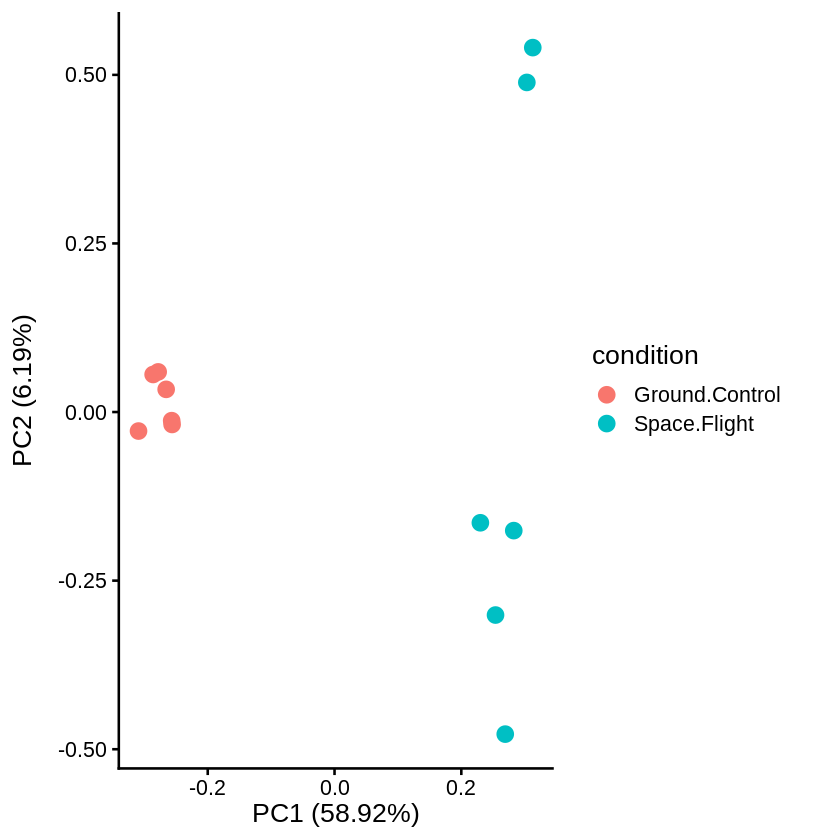

In [103]:
## Create your PCA plot without samples labeled
autoplot(PCA_dte, data=sampleTable, colour='condition',
         label=FALSE, label.size=5, size=4, alpha=1) + theme_classic(base_size = 16)

## Save your PCA plot without samples labeled
ggsave(file.path(DTE_pca, paste(GLDS, "filtered_on", g1mod, "v", g2mod, "PCA_DTE_nolabels.png", sep="_")), width = 8.5, height = 6, dpi = 300)

**Compare this PCA plot to the plot we made in [Step 3d](#3d.-DESeq2-Step-3:-Hypothesis-Testing-with-Wald-Test) using all normalized counts, and answer the following questions:**

1. How has the percent of variance explained by PC1 changed? What is responsible for this change?
   
2. Is there anything interesting to note about PC2?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

This will depend on the dataset you're analyzing. If the count data showed samples separating by treatment group in PC1, then the percent of variance explained by will have PC1 increased.

We subset to only differentially expressed transcripts, so if PC1 is indicative of the differences between group 1 and group 2 samples, when we only use transcripts that we know are significantly different between these groups, PC1 will now account for even more of the overall differences among samples.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

This will depend on the dataset you're analyzing. If the count data showed samples separating by treatment group in PC1 and PC2 likely accounted for technical differences between samples, then if the percent of variance explained by PC2 also increased, it would suggest differences in significant DEGs among samples within the same group. However, if the percent of variance explained by PC2 decreased, it would suggest fewer differences in significant DEGs among samples within the same group.

</details>
</div>

<br>

**Challenge**

Use the code block below to try creating more plots with autoplot, changing the parameters and see how the PCA plot changes.

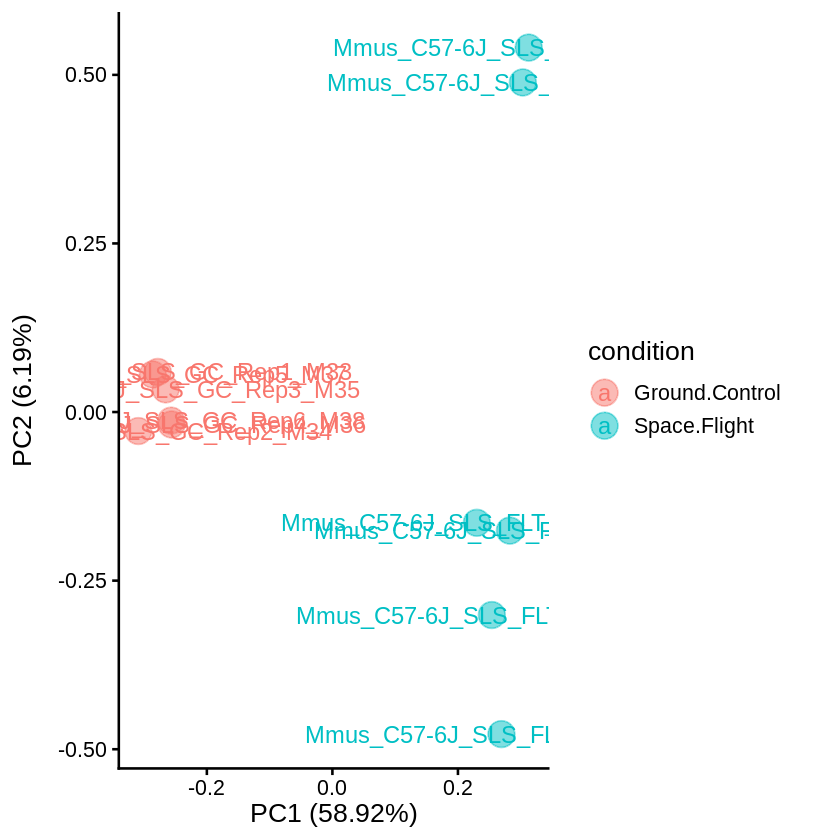

In [104]:
autoplot(PCA_dte, data=sampleTable, colour='condition',
         label=TRUE, label.size=5, size=7, alpha=0.5) + theme_classic(base_size = 16)

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

**One way of doing this:**
> _Note: Adding lables to the samples will help determine which samples are in each of the clusters we see for each group. This will allow us to start investigating what could be causing any differences observed among sampes within the same group._

```R
autoplot(PCA_dte, data=sampleTable, colour='condition',
         label=TRUE, label.size=5, size=7, alpha=0.5) + theme_classic(base_size = 16)
```


</details>
</div>

<br>

---

<a class="anchor" id="heatmap"></a>
## 5b. Heatmap

Heatmaps are commonly used to visualize transcript expression data to see overall trends between samples in large lists of transcripts. Here, we will use a heatmap to examine the expression of our DEGs in the `g1` and `g2` samples.

Before creating the heatmap, we'll first scale the counts data between 0 and 1. This makes it easier to visualize relative expression levels.

In [105]:
exp_dte_scale <- (exp_dte - min(exp_dte)) / (diff(range(exp_dte)))

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `exp_dte_scale <- (exp_dte - min(exp_dte)) / (diff(range(exp_dte)))`:  
    - This command scales the expression data `exp_dte` to a range between 0 and 1 (also known as _min-max scaling_).
  
    - `(exp_dte - min(exp_dte))`:  
        - Subtracts the minimum value in `exp_dte` from each element, shifting the data so that the minimum value becomes 0.
  
    - `diff(range(exp_dte))`:  
        - Calculates the difference between the maximum and minimum values in `exp_dte`, which is the range of the data.
  
    - `/ (diff(range(exp_dte)))`:  
        - After subtracting the minimum value from each value in `exp_dte`, the data is divided by the range, normalizing the values so that they fall between 0 and 1.
  
    - `exp_dte_scale`:  
        - The result is assigned to `exp_dte_scale` variable, which contains the scaled transcript expression data with values ranging from 0 to 1.

</div>

<br>

Now we're ready to create the heatmap:
> _**Note**_: Change the row title of the heatmap to match the number of differentiall expressed transcripts (DETs) using the dimensions of the `exp_dte` data frame.

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


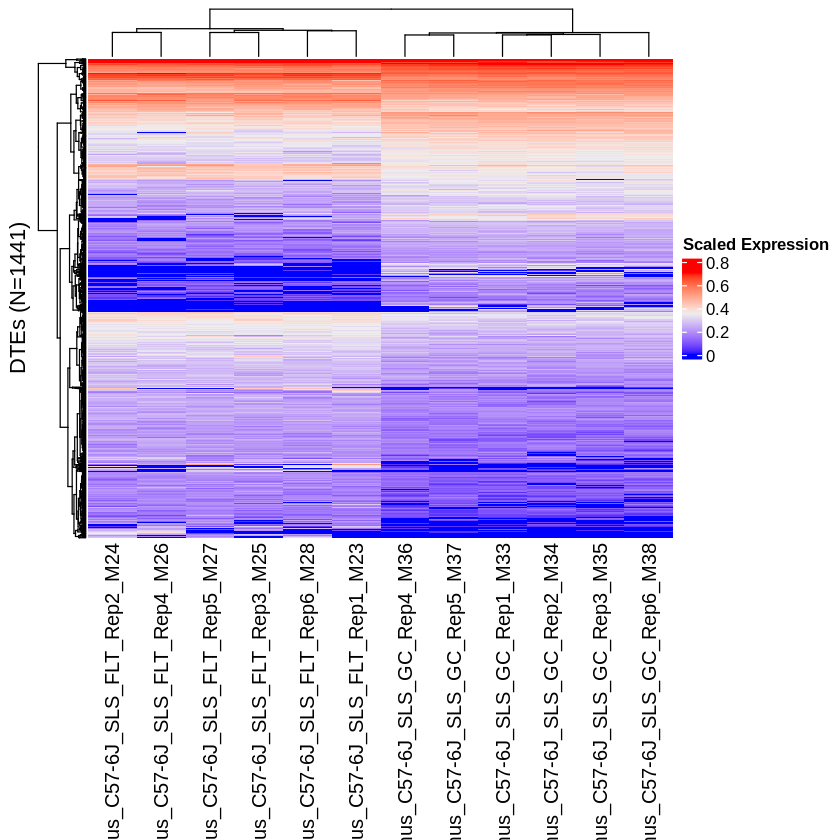

In [106]:
## Change the row_title N number to match the number of differentially expressed transcripts for your comparison ##
Heatmap(exp_dte_scale, show_row_names=FALSE, row_title="DTEs (N=1441)",
   heatmap_legend_param = list(title="Scaled Expression"))

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `Heatmap(exp_dte_scale, show_row_names=FALSE, row_title="DETs (N=1441)", heatmap_legend_param = list(title="Scaled Expression"))`:  
    - Creates a heatmap visualization of the scaled transcript expression data stored in `exp_dte_scale`.

    - `exp_dte_scale`:  
        - The input data for the heatmap, containing the scaled transcript expression values for differentially expressed transcripts (DETs).
  
    - `show_row_names=FALSE`:  
        - Suppresses the display of row names (transcript names) to declutter the heatmap.
          > _Note: With so many DETs, the row names would be difficult to see. However, if there were fewer DETs, e.g. <100, then showing the row names could be useful._
  
    - `row_title="DETs (N=1441)"`:  
        - Sets the title for the rows of the heatmap, indicating that it represents _1441 differentially expressed transcripts (DETs)_.
  
    - `heatmap_legend_param = list(title="Scaled Expression")`:  
        - Customizes the heatmap legend by setting its title to "Scaled Expression", which clarifies that the heatmap represents the scaled expression values (ranging from 0 to 1).

</div>

<br>

Next, we'll generate the heatmap again, but this time, let's save it to a variable:

In [107]:
## Change the row_title N number to match the number of differentially expressed transcripts for your comparison ##
heatmap = Heatmap(exp_dte_scale, show_row_names=FALSE, row_title="DTEs (N=1441)",
   heatmap_legend_param = list(title="Scaled Expression"))

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


Now we can use the variable `heatmap` to save the image as a pdf with the function, `save_pdf()`:

In [108]:
save_pdf(heatmap, file.path(DTE_heatmaps, paste(GLDS, g1mod, "v", g2mod, "heatmap_DTE.pdf", sep="_")),
        width = 5, height = 5, units = c("in"))

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `save_pdf(heatmap, file.path(DTE_heatmaps, paste(GLDS, g1mod, "v", g2mod, "heatmap_DTE.pdf", sep="_")), width = 5, height = 5, units = c("in"))`:  
    - Saves the heatmap to a PDF file, specifying the file path and dimensions.
  
    - `save_pdf()`:  
        - The function we're using to save our heatmap as a PDF file. It takes in parameters for the plot object (a heatmap in our case), the file path where the PDF should be saved, and the dimensions for the output.
  
    - `heatmap`:  
        - The heatmap object to be saved as a PDF. This is the heatmap we created with the `ComplexHeatmap` package above.
  
    - `file.path(DTE_heatmaps, paste(GLDS, g1mod, "v", g2mod, "heatmap_DTE.pdf", sep="_"))`:  
        - Creates a valid file path to save the PDF.  
        - `DTE_heatmaps`: The variable containing the directory where the PDF will be saved.
        - `paste(GLDS, g1mod, "v", g2mod, "heatmap_DTE.pdf", sep="_")`: The filename for the saved PDF, created by combining the values held in the `GLDS`, `g1mod`, `g2mod` variables and ending in "heatmap_DTE.pdf".
  
    - `width = 5`:  
        - Specifies the width of the PDF. In this case, the width is set to 5 units (depending on the unit defined in the `units` parameter).
  
    - `height = 5`:  
        - Specifies the height of the PDF. The height is also set to 5 units.
  
    - `units = c("in")`:  
        - Defines the units for the dimensions. Here we use "in" for inches).

</div>

<br>

**Use the heatmap to answer the following questions:**

1. What overall trends do you notice in the expression of the DETs in samples within the same group? What about samples in different groups?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b> Q1 Solution</b></summary>

<br>

The expression of the DETs is expected to be more similar among samples within the same group than samples in different groups.

</details>
</div>

<br>


**Challenge:** Recall that before generating the heatmap, we first scaled the expression data. Use the following code block to see what the heatmap looks like if you don't scale the data.
> Hint: Use the `Heatmap()` function again, but replace `exp_dte_scale` with `exp_dte`.

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


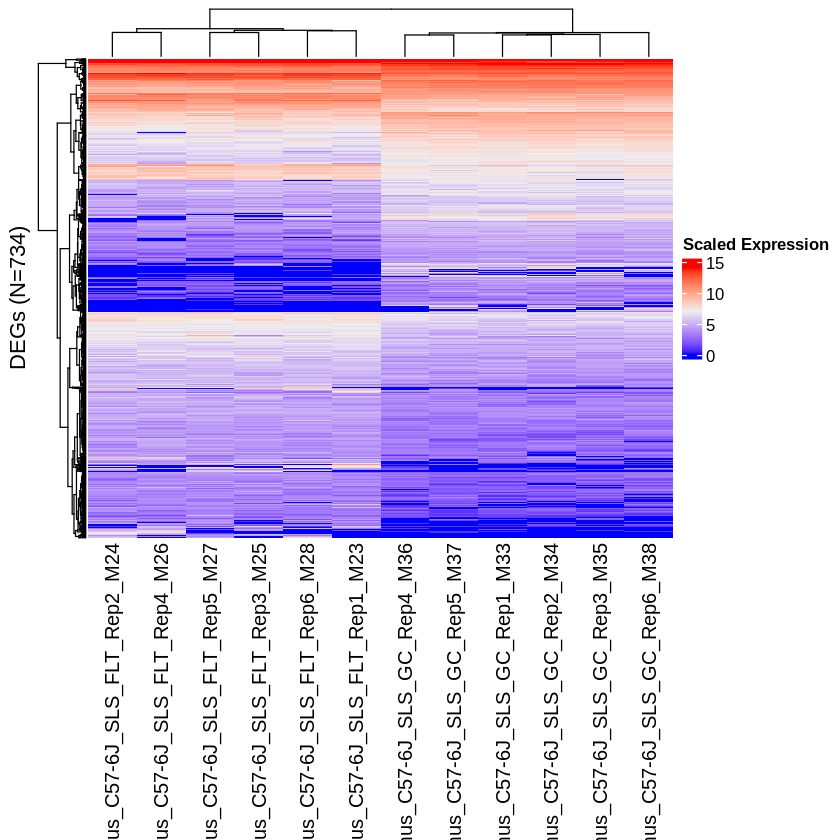

In [109]:
Heatmap(exp_dte, show_row_names=FALSE, row_title="DEGs (N=734)",
   heatmap_legend_param = list(title="Scaled Expression"))

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

```R
Heatmap(exp_dte, show_row_names=FALSE, row_title="DEGs (N=734)",
   heatmap_legend_param = list(title="Scaled Expression"))
```

</details>
</div>

<br>


What if we don't log transform the data, either?

**Spoiler alert:** This crashes the kernel in the Jupyter Hub! Why do you think this is?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

If we don’t log transform the data, the expression values span from 1 to over 30,000 (depending on your dataset).

If run Heatmap() on the non log transformed data, the function tries to fit all those values into the heatmap which is very computationally intensive and causes the kernel to crash.

</details>
</div>

<br>


We've generated this plot locally and provided it below. Is this a useful plot?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

No, it is very difficult to see differences between groups because all of the color differences are concentrated at the highest values.

</details>
</div>

<br>


<br>

<div align="center">
<img src="https://raw.githubusercontent.com/torres-alexis/GeneLab-Training/refs/heads/GL4U_RNAseq_Colab/images/rnaseq-dte-heatmap.png" alt="rnaseq heatmap">
</div>

<br>

<a class="anchor" id="volcano"></a>
## 5c. Volcano Plot

Next, let's make a volcano plot to identify a few interesting transcripts. A volcano plot is a scatterplot which shows the relationship of the adjusted p-value to the log2 fold change. Transcripts with large fold changes that are also statistically significant by adjusted p-value are labeled.

First, we'll define the settings in the `EnhancedVolcano()` function to use the cutoff values that were used above: log2 fold change cutoff > |1|, and an adjusted p-value cutoff of < 0.05.

>_**Note**_: You can read more about the `EnhancedVolcano()` function and see some examples by clicking [here](https://bioconductor.org/packages/release/bioc/vignettes/EnhancedVolcano/inst/doc/EnhancedVolcano.html).

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


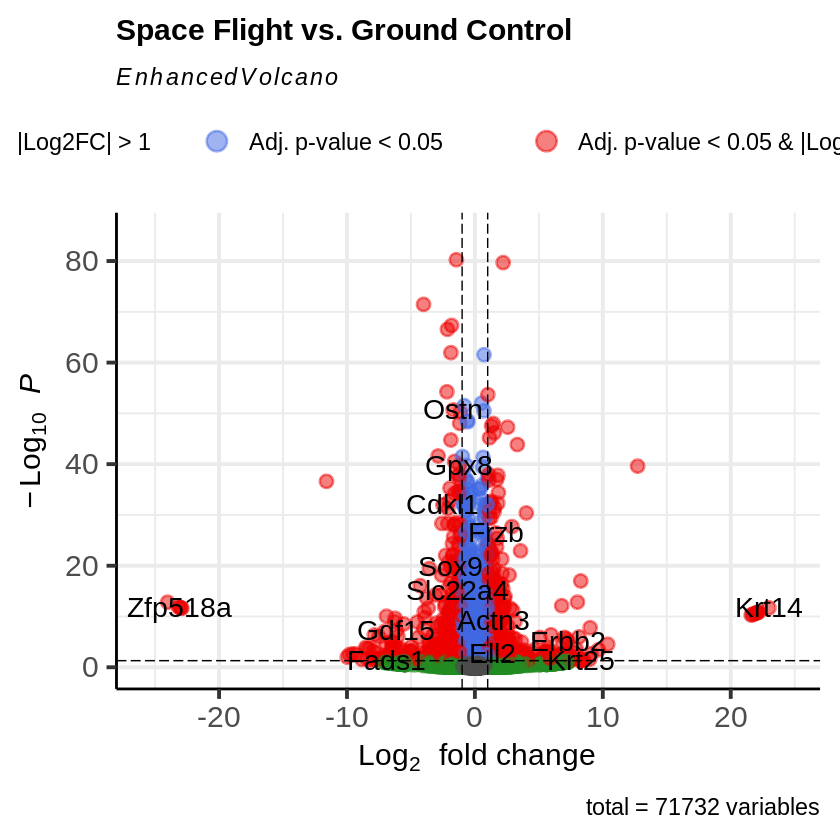

In [110]:
## Volcano plot showing transcripts differentially expressed in group 1 vs group 2 ##
EnhancedVolcano(DTE_output_table,
    lab = DTE_output_table$SYMBOL,
    x = paste("Log2fc_(", g1, ")v(", g2, ")", sep=""),
    y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep=""),
    title = paste(g1, " vs. ", g2, sep=""),
    legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05',
      'Adj. p-value < 0.05 & |Log2FC| > 1'),
    pCutoff = 5e-2,
    FCcutoff = 1,
    pointSize = 3.0,
    labSize = 6.0,
    colAlpha=0.5)

## Save your volcano plot ##
ggsave(file.path(DTE_volcano, paste(GLDS, g1mod, "v", g2mod, "volcano_DTE.png", sep="_")), width = 11, height = 8.5, dpi = 300)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `EnhancedVolcano()`:  
    - The function used to create a _volcano plot_ to visualize differentially expressed transcripts from data in a dataframe (`DTE_output_table`), by plotting log fold change against adjusted p-value.
  
    - `DTE_output_table`:  
        - The data frame containing the differential transcript expression results, which includes log fold change, adjusted p-values, and gene symbols.

    - `lab = DTE_output_table$SYMBOL`:  
        - Labels the points (transcripts) in the volcano plot using the transcript symbols stored in the `SYMBOL` column of `DTE_output_table`.

    - `x = paste("Log2fc_(", g1, ")v(", g2, ")", sep="")`:  
        - Defines the x-axis values for the volcano plot, representing the log2 fold change between group 1 and group 2.

    - `y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep="")`:  
        - Defines the y-axis values for the plot, representing the adjusted p-value for the comparison between group 1 and group 2.

    - `title = paste(g1, " vs. ", g2, sep="")`:  
        - Sets the title of the volcano plot to "group 1 versus group 2".

    - `legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05', 'Adj. p-value < 0.05 & |Log2FC| > 1')`:  
        - Customizes the labels in the plot legend to represent different categories of significance:  
            - `NS`: Not significant,  
            - `|Log2FC| > 1`: Transcripts with a log2 fold change greater than 1 or less than -1,  
            - `Adj. p-value < 0.05`: Transcripts with a significant adjusted p-value, < 0.05,  
            - `Adj. p-value < 0.05 & |Log2FC| > 1`: Transcripts that meet both significance and fold change criteria.

    - `pCutoff = 5e-2`:  
        - Sets the cutoff for the adjusted p-value to 0.05 (5e-2) to define statistical significance.

    - `FCcutoff = 1`:  
        - Sets the fold change cutoff to 1, so transcripts with a log2 fold change greater than 1 or less than -1 are considered biologically meaningful.

    - `pointSize = 3.0`:  
        - Specifies the size of the points (transcripts) in the plot.

    - `labSize = 6.0`:  
        - Sets the size of the transcript labels in the plot.

    - `colAlpha=0.5`:  
        - Adjusts the transparency of the points (transcripts) in the plot.

<br>

- `ggsave()`:  
    - Function used to save the volcano plot as a _PNG_ file in the `DTE_volcano` directory.

    - `file.path(DTE_volcano, paste(GLDS, g1mod, "v", g2mod, "volcano_DTE.png", sep="_"))`:  
        - Creates the file path for saving the volcano plot. In this case, the file will be saved in the `DTE_volcano` directory and named by combining the values held in the `GLDS`, `g1mod`, `g2mod` variables and ending in "volcano_DTE.png".

    - `width = 11, height = 8.5`:  
        - Specifies the dimensions of the saved PNG file (11 inches wide and 8.5 inches high).

    - `dpi = 300`:  
        - Sets the resolution of the saved PNG file to 300 dpi, which is suitable for publication-quality images.

</div>

<br>


**Use the volcano plot (and our collective conscious - aka the internet) to answer the following questions:**

1. Which transcript has the smallest adjusted p-value that still passes our Log2FC cutoff?
   
2. Is that transcript more highly expressed in `g1` or `g2` samples? How do you know?

3. Which transcript is most highly differentially expressed in `g1`? Does this transcript also pass the adjusted p-value cutoff?

4. For the most significant differentially expressed transcript, see if you can find its biological function (feel free to use a search engine, e.g. Google, to help you out). Are you able to find an annotated function?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The transcript with the smallest adjusted p-value that still passes our Log2FC cutoff will be the transcript with the highest value on the y-axis that is also outside (less than or greater than) the two vertical lines representing our Log2FC cutoff values.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

If the transcript has a positive Log2FC value then it is more highly expressed in group 1 samples but if it has a negative Log2FC value then it is more highly expressed in group 2 samples because we plotted the group 1 vs group 2 comparison.

</details>
</div>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q3 Solution</b></summary>

<br>

The most highly differentially expressed transcript in group 1 is the transcript with the largest Log2FC value.  

If that transcript is also above the horizontal line, representing our adjusted p-value cutoff, then it does pass the adjusted p-value cutoff.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q4 Solution</b></summary>

<br>

This depends on what the most significant differentially expressed transcript is in your dataset. You can search your transcript name on [GeneCards](https://www.genecards.org/) to find out more, including an annotated function(s) if available.  

</details>
</div>

<br>

**Challenge:** Use the code blocks below to create another volcano plot (or two) with different adjusted p-value and log2FC cutoffs and see how the plot changes.
> _**Hint**_: Start with the `EnhancedVolcano()` command above then change the values corresponding to the adjusted p-value and log2FC cutoffs. If you're unsure what those are, take a look at the `EnhancedVolcano()` documentation [here](https://bioconductor.org/packages/release/bioc/vignettes/EnhancedVolcano/inst/doc/EnhancedVolcano.html).

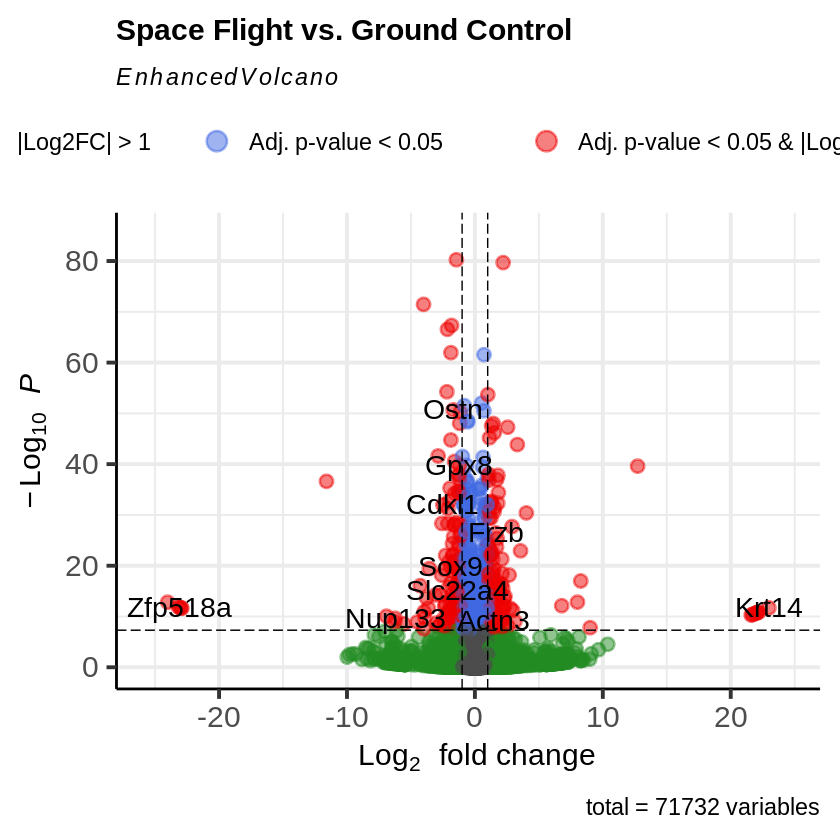

In [111]:
EnhancedVolcano(DTE_output_table,
    lab = DTE_output_table$SYMBOL,
    x = paste("Log2fc_(", g1, ")v(", g2, ")", sep=""),
    y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep=""),
    title = paste(g1, " vs. ", g2, sep=""),
    legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05',
      'Adj. p-value < 0.05 & |Log2FC| > 1'),
    pCutoff = 5e-8,
    FCcutoff = 1,
    pointSize = 3.0,
    labSize = 6.0,
    colAlpha=0.5)

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

One example with the adjusted p-value cutoff more stringient:

```R
EnhancedVolcano(DTE_output_table,
    lab = DTE_output_table$SYMBOL,
    x = paste("Log2fc_(", g1, ")v(", g2, ")", sep=""),
    y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep=""),
    title = paste(g1, " vs. ", g2, sep=""),
    legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05',
      'Adj. p-value < 0.05 & |Log2FC| > 1'),
    pCutoff = 5e-8,
    FCcutoff = 1,
    pointSize = 3.0,
    labSize = 6.0,
    colAlpha=0.5)  
```

</details>
</div>

<br>

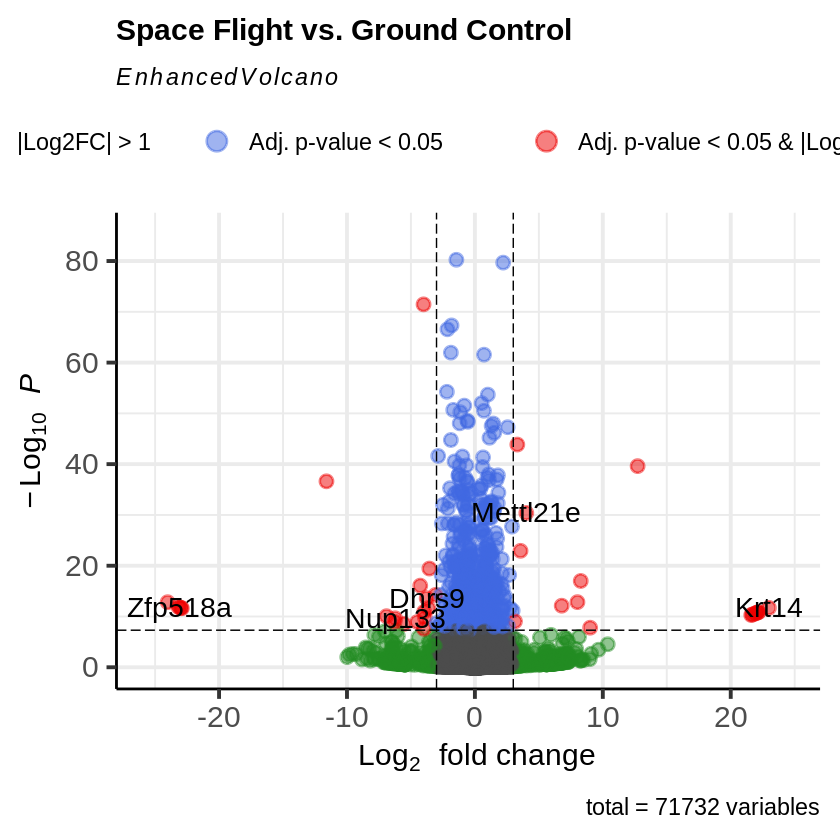

In [112]:
EnhancedVolcano(DTE_output_table,
    lab = DTE_output_table$SYMBOL,
    x = paste("Log2fc_(", g1, ")v(", g2, ")", sep=""),
    y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep=""),
    title = paste(g1, " vs. ", g2, sep=""),
    legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05',
      'Adj. p-value < 0.05 & |Log2FC| > 1'),
    pCutoff = 5e-8,
    FCcutoff = 3,
    pointSize = 3.0,
    labSize = 6.0,
    colAlpha=0.5)

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Solution</b></summary>

<br>

Another example with the adjusted p-value and the log2 fold change cutoffs more stringient:

```R
EnhancedVolcano(DTE_output_table,
    lab = DTE_output_table$SYMBOL,
    x = paste("Log2fc_(", g1, ")v(", g2, ")", sep=""),
    y = paste("Adj.p.value_(", g1, ")v(", g2, ")", sep=""),
    title = paste(g1, " vs. ", g2, sep=""),
    legendLabels=c('NS','|Log2FC| > 1','Adj. p-value < 0.05',
      'Adj. p-value < 0.05 & |Log2FC| > 1'),
    pCutoff = 5e-8,
    FCcutoff = 3,
    pointSize = 3.0,
    labSize = 6.0,
    colAlpha=0.5)  
```

</details>
</div>

<br>

---

<a class="anchor" id="gsea"></a>
## 5d. Gene Set Enrichment Analysis (GSEA)

Finally, let's perform Gene Set Enrichment Analysis ([GSEA](https://www.gsea-msigdb.org/gsea/index.jsp)). GSEA is a computational method used to determine whether predefined sets of genes (such as pathways or functional groups) show statistically significant differences in expression between different experimental conditions (e.g. spaceflight and ground control).

<br>

**Note: GSEA will not work using transcript IDs. If you want to run GSEA, you can do so using geneIDs associated with transcripts by running the 03-RNAseq_analysis_isoforms_anyOSD_geneAnnot JN.**

<br>

#### Set DTE Filtering Parameters

Specify the filtering parameters to use to prepare your DTE output table for subsequent GSEA:

- **mean_exp_cutoff**: Cut off value for the average transcript expression across all samples. Transcripts below this value will be removed.
- **rank_var**: The DESeq2 results statistic you want to use to rank your features (transcripts), options include:
  - `Log2fc`: Log(2) fold change
  - `Stat`: Wald statistic
  - `P.value`: p-value
  - `Adj.p.value`: p-value adjusted for multiple comparisons testing
- **keytype**: The gene IDs used in your DTE analysis above, options include:
  - `ENSEMBL`: For animals
  - `TAIR`: For plants

In [113]:
mean_exp_cutoff <- 50
rank_var <- "Stat"
keytype <- "ENSEMBL" ## Change ENSEMBL to TAIR for plant studies ##

<br>

#### Filter DTE Results On Contrast of Interest

In [114]:
## Pull DESeq2 results columns from the DTE table ##
IDs <- DTE_output_table %>% dplyr::select( !!rlang::sym("ENSEMBLTRANS"))
all_mean <- DTE_output_table %>% dplyr::select(All.mean)
log2fc <- DTE_output_table %>% dplyr::select( !!rlang::sym(paste0("Log2fc_(",g1,")v(",g2,")")))
stat <- DTE_output_table %>% dplyr::select( !!rlang::sym(paste0("Stat_(",g1,")v(",g2,")")))
pvalue <- DTE_output_table %>% dplyr::select( !!rlang::sym(paste0("P.value_(",g1,")v(",g2,")")))
padj <- DTE_output_table %>% dplyr::select( !!rlang::sym(paste0("Adj.p.value_(",g1,")v(",g2,")")))

## Combine all DESeq2 results columns from the DTE table ##
DTE_res <- cbind(IDs, all_mean, log2fc, stat, pvalue, padj)

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `IDs <- DTE_output_table %>% dplyr::select( !!rlang::sym("ENSEMBLTRANS"))`:  
    - Selects the column from `DTE_output_table` that matches "ENSEMBLTRANS".  
    - `!!rlang::sym("ENSEMBL")`: Uses `rlang::sym` to pull the info stored in the "ENSEMBLTRANS" column and the `!!` operator to remove the quotes so it can be evaluated within the `dplyr::select()` function.

- `all_mean <- DTE_output_table %>% dplyr::select(All.mean)`:  
    - Selects the `All.mean` column from `DTE_output_table`, which contains the mean expression value for each transcript across all samples.

- `log2fc <- DTE_output_table %>% dplyr::select( !!rlang::sym("Log2fc_(",g1,")v(",g2,")") )`:  
    - Selects the column containing the log2 fold change values for the comparison between _group 1_ and _group 2_ conditions.  
    - `!!rlang::sym("Log2fc_(",g1,")v(",g2,")")`: Dynamically references the column name even though it contains special characters (parentheses). This ensures the column is correctly interpreted by `dplyr::select()`.

- `stat <- DTE_output_table %>% dplyr::select( !!rlang::sym("Stat_(",g1,")v(",g2,")") )`:  
    - Selects the column that holds the statistical test values (e.g., Wald statistic) for the _group 1_ vs _group 2_ comparison.

- `pvalue <- DTE_output_table %>% dplyr::select( !!rlang::sym("P.value_(",g1,")v(",g2,")") )`:  
    - Selects the column that contains the raw p-values for the _group 1_ vs _group 2_ comparison.

- `padj <- DTE_output_table %>% dplyr::select( !!rlang::sym("Adj.p.value_(",g1,")v(",g2,")") )`:  
    - Selects the column with the adjusted p-values (corrected for multiple testing) for the _group 1_ vs _group 2_ comparison.

<br>

- `DTE_res <- cbind(IDs, all_mean, log2fc, stat, pvalue, padj)`:  
    - Combines all the selected columns (IDs, All.mean, Log2FC, Stat, P.value, and Adj.p.value) into a new data frame `DTE_res` using `cbind()`.  
    - This new table contains relevant information for each gene, including identifiers, mean expression, log2 fold changes, statistical values, and p-values.

</div>

<br>

Remove low expressing genes from your `DTE_res` table:

In [115]:
DTE_res <- DTE_res %>% dplyr::filter(All.mean > mean_exp_cutoff)

Look at the dimensions of your `DTE_res` table after filtering low expressing genes:

In [116]:
dim(DTE_res)

[1] 22161     6

**Use the dimensions of your `DTE_res` table after filtering low expressing transcripts to answer the following question:**

1. How many transcripts were removed?

  > *Hint: Subtract this value from the number of features in the `DEG_output_table`*

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The dim() function displays rows by columns, which for us represents genes and samples, respectively. Therefore the number of genes removed is equal to the number of rows in the `DEG_output_table` minus the number of rows in the `DTE_res` table.

</details>
</div>

<br>

Take a look at your `DTE_res` table:

In [117]:
head(DTE_res)

,ENSEMBLTRANS,All.mean,Log2fc_(Space Flight)v(Ground Control),Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSMUST00000000001,901.3958,-0.08081968,-1.191156,2.335922e-01,5.657010e-01
2,ENSMUST00000000028,94.7329,0.21703311,1.083449,2.786092e-01,6.209253e-01
3,ENSMUST00000132294,103.3768,-0.50154064,-2.745068,6.049830e-03,4.714046e-02
4,ENSMUST00000136359,76145.7085,-0.56852733,-6.498677,8.102967e-11,4.632841e-09
5,ENSMUST00000152754,1855.2568,-0.51461062,-4.683711,2.817266e-06,6.897527e-05
6,ENSMUST00000228259,706.5188,-0.26091636,-1.009254,3.128530e-01,6.563779e-01


<br>

#### Rank DTE Results

GSEA requires the input transcript list to be ranked in order to evaluate whether transcripts in the predefined set are primarily located at the top (upregulated) or bottom (downregulated) of the ranked list, thus revealing biologically meaningful trends that may not be apparent from single-gene analyses.

Any of the DESeq2 results columns can be used to rank our transcript list. Here we use the Wald statistic, defined in the `rank_var` variable above, to rank our transcript, which is commonly used for GSEA.

Rank the features (transcripts) in our `DTE_res` dataframe using our `rank_var` specified above:

In [118]:
DTE_res_ranked <- DTE_res %>% dplyr::arrange(desc( !!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")"))))

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `DTE_res_ranked <- DTE_res %>% dplyr::arrange(desc( !!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")"))))`:  
    - This command ranks (or arranges) the rows of the `DTE_res` data frame based on a specific column, with the order set to _descending_.

    - `DTE_res`:  
        - The data frame holding the DESeq2 results (previously created) which contains the data columns we selected above.

    - `%>%`:  
        - The _pipe operator_ allows for chaining functions together, making the code cleaner and easier to read. It passes `DTE_res` into the next function (`dplyr::arrange`).

    - `dplyr::arrange()`:  
        - A function from the `dplyr` package that _rearranges_ the rows of a data frame based on one or more columns. The default sorting order is ascending unless `desc()` is used.

    - `desc()`:  
        - This ensures that the sorting is done in _descending order_ (from largest to smallest values).

    - `!!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")"))`:  
        - Dynamically constructs and evaluates the column name used for ranking.  
        - `paste0(rank_var, "_(",g1,")v(",g2,")")`: Concatenates the values stored in the `rank_var`, `g1`, and `g2` variables to create the full column name.
        - `!!rlang::sym()`: Converts the concatenated string into a symbol (a reference to a column) and evaluates it, ensuring `arrange()` can use it as the sorting criterion.

</div>

<br>

View your `DTE_res_ranked` table to make sure the data are now ranked in descending order based on your `rank_var` column:

In [119]:
head(DTE_res_ranked)

,ENSEMBLTRANS,All.mean,Log2fc_(Space Flight)v(Ground Control),Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSMUST00000075301,5345.888,2.2086540,19.51360,8.413535e-85,2.066070e-80
2,ENSMUST00000031894,2869.793,0.7123516,17.17738,3.922501e-66,2.752083e-62
3,ENSMUST00000090469,20553.218,1.0126663,16.07672,3.715519e-58,2.027559e-54
4,ENSMUST00000028689,2744.993,0.5282811,15.82961,1.944313e-56,9.549107e-53
5,ENSMUST00000051389,33245.889,0.7075366,15.59241,8.198174e-55,3.097207e-51
6,ENSMUST00000107358,7885.246,1.4334652,15.19825,3.632054e-52,9.910059e-49


Next, we'll extract our sorted `rank_var` column to create our transcript list that we will use to perform GSEA:

In [120]:
trans_list <- DTE_res_ranked %>% dplyr::select( !!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")"))) %>% pull

## Add IDs from the DTE_res_ranked dataframe to the trans_list ##
names(trans_list) <- DTE_res_ranked %>% dplyr::select( !!rlang::sym("ENSEMBLTRANS")) %>% pull

## View your ranked gene_list ##
head(trans_list)

ENSMUST00000075301 ENSMUST00000031894 ENSMUST00000090469 ENSMUST00000028689 ENSMUST00000051389 ENSMUST00000107358 
          19.51360           17.17738           16.07672           15.82961           15.59241           15.19825

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `trans_list <- DTE_res_ranked %>% dplyr::select( !!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")"))) %>% pull`:  
    - Creates `trans_list`, a vector that contains the values from a dynamically specified column in the `DTE_res_ranked` data frame.
  
    - `dplyr::select( !!rlang::sym(paste0(rank_var,"_(",g1,")v(",g2,")")))`:  
        - Dynamically constructs the column name by concatenating `rank_var` and `"_(",g1,")v(",g2,")"` to select the column used for ranking.  
        - `!!rlang::sym()`: Converts the constructed string into a symbol to select the column in `dplyr::select()`.
  
    - `pull`:  
        - Extracts the selected column as a vector from the data frame.

- `names(trans_list) <- DTE_res_ranked %>% dplyr::select( !!rlang::sym(keytype)) %>% pull`:  
    - Assigns names to the elements of `trans_list` using IDs from the `DTE_res_ranked` data frame.

    - `dplyr::select( !!rlang::sym(keytype))`:  
        - Dynamically selects the "ENSEMBL" column from the `DTE_res_ranked` data frame, which contains the ENSEMBL IDs.

    - `pull`:  
        - Extracts this column as a vector to be used as the names for `trans_list`.

</div>

<br>

<br>

#### Set GSEA Parameters

To perform GSEA, we'll set parameters to specify how we want the analysis performed. Here is a description of the parameters we'll be specifying in the code block below:

- **ont**: The sub-ontology to use, options include:
  - `BP`: Biological Processes
    > Focuses on the pathways and larger biological processes in which a gene product is involved. Examples include processes like cell division, immune response, or signal transduction.
  - `MF`: Molecular Function
    > Describes the biochemical activities of gene products at the molecular level. Examples include functions like enzyme activity, binding affinity, or transport activity.
  - `CC`: Cellular Component
    > Refers to where gene products are located within a cell or their subcellular structures. Examples include mitochondria, nucleus, cell membrane, or protein complexes.
  - `ALL`: Use all three sub-ontologies
- **minGSSize**: Minimum size of a gene set for testing. Gene sets containing a total number of genes below this threshold will be excluded.
- **maxGSSize**: Maximum size of a gene set for testing. Gene sets containing a total number of genes above this threshold will be excluded.
- **pvalueCutoff**: The adjusted p-value cutoff on enrichment tests to report.
- **pAdjustMethod**: Method to use to correct for multiple comparisons testing, options include:
> You can learn more about each of the methods listed below in [this paper](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5506159/).
  - `holm`: Holm adjustment
  - `hochberg`: Hochberg adjustment
  - `hommel`: Hommel adjustment
  - `bonferroni`: Bonferroni adjustment
  - `BH`: Benjamini-Hochberg adjustment
  - `BY`: Benjamini and Yekutieli adjustment
  - `fdr`: false discovery rate
  - `none`: Do not correct for multiple comparisons testing

In [121]:
ont <- "BP"
minGSSize <- 10
maxGSSize <- 500
pvalueCutoff <- 0.05
pAdjustMethod <- "BH"

<br>

#### Run GSEA Using Gene Ontology (GO)

In this section we will use geneset enrichment analyses provided in the [clusterProfiler](https://bioconductor.org/packages/release/bioc/html/clusterProfiler.html) package on [Bioconductor](http://www.bioconductor.org/). There are a variety of different tools in `clusterProfiler` that allow you to run GSEA using several different types of gene sets. Here we use the genesets associated with the [gene ontologies (GO)](http://geneontology.org/) of our species of interest. You are welcome (and encouraged) to check out the [clusterProfiler](https://bioconductor.org/packages/release/bioc/manuals/clusterProfiler/man/clusterProfiler.pdf) documentation and set up additional code blocks to run GSEA using different types of gene sets.

In [122]:
gse <- gseGO(geneList = trans_list,
             ont = ont,
             keyType = keytype,
             minGSSize = minGSSize,
             maxGSSize = maxGSSize,
             pvalueCutoff = pvalueCutoff,
             pAdjustMethod = pAdjustMethod,
             OrgDb = ann.dbi,
             by = "fgsea")

Warning message in packageDescription(pkgname, fields = "Version"):
“no package '--> No gene can be mapped....' was found”
Warning message in packageDescription(pkgname, fields = "Version"):
“no package '--> Expected input gene ID: ' was found”
Warning message in packageDescription(pkgname, fields = "Version"):
“no package '--> return NULL...' was found”


<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `gse <- gseGO(geneList = gene_list, ont = ont, keyType = keytype, minGSSize = minGSSize, maxGSSize = maxGSSize, pvalueCutoff = pvalueCutoff, pAdjustMethod = pAdjustMethod, OrgDb = ann.dbi, by = "fgsea")`:  
    - This command performs _Gene Set Enrichment Analysis (GSEA)_ using the _Gene Ontology (GO)_ framework, analyzing the ranked `gene_list` to identify enriched gene sets in a specific ontology (e.g., Biological Process, Molecular Function, or Cellular Component).

    - `gseGO()`:  
        - A function from the `clusterProfiler` R package that performs GSEA specifically for Gene Ontology. It evaluates whether any GO terms are significantly enriched at the top or bottom of the ranked gene list.

    - `geneList = gene_list`:  
        - The ranked list of genes we generated above that GSEA will analyze for enrichment.

    - `ont`, `keyType`, `minGSSize`, `maxGSSize`, `pvalueCutoff`, `pAdjustMethod`:  
        - Specifies the parameters described [above](#Set-GSEA-Parameters).

    - `OrgDb = ann.dbi`:  
        - The organism-specific annotation database used to map gene identifiers to GO terms. Recall that `ann.dbi` is the variable we set in [step 4b](#4b.-Add-Gene-Annotations) above.

    - `by = "fgsea"`:  
        - Specifies the algorithm used for GSEA. Here, `"fgsea"` refers to _fast GSEA_, a more efficient algorithm for computing GSEA results, especially useful for large gene sets.

</div>

<br>

Next we will convert the results of our GSEA to a dataframe and save it as a CSV file, then view our GSEA output table:

<div class="alert alert-block alert-info">
<b>GSEA output table content</b><br>

The GSEA output table contains the following columns:

- **ID**: Gene set IDs, here we are using Gene Ontologies (GO).
- **Description**: Indicates the name of the sub-ontology set, the sub-ontology set type defined as the `ont` variable specified above.
- **setSize**: The number of genes in the gene set, after filtering out genes that are not present in the input expression dataset.
- **enrichmentScore**: Unnormalized enrichment score (ES), determined based on how much a gene set is overrepresented at the top or bottom of a ranked list of genes. A positive ES indicates gene set enrichment at the top of the ranked list whereas a negative ES indicates gene set enrichment at the bottom of a ranked list.
- **NES**: Normalized enrichment score, the ES after correcting for differences in ES between gene sets due to differences in the size of the gene sets evaluated.
- **pvalue**: An enrichment p-value representing the statistical significance of the ES, which does not take into account differences in gene set size and has not been adjusted for multiple hypothesis testing. (This is not a useful metric to determine significance.)
- **p.adjust**: A p-value adjusted for multiple testing using the correction method specified with the `pAdjustMethod` variable above.
- **qvalue**: A measure of the false discovery rate (FDR), which is the estimated probability that a gene set with a given NES represents a false positive finding. The closer the qvalue is to zero, the greater the perturbation of the gene set.
  > _Note: Although q-values are always positive (between 0 and 1), the gsea augments the value with either a positive or negative sign to indicate up-regulation or down-regulation, respectively, of a gene set._
- **rank**: The position in the ranked list at which the maximum enrichment score occurred. Genesets that achieve the maximum enrighment score towards the top or bottom of the ranked list provided are the most interesting.
- **leading_edge**: 3 statistics that define the leading edge subset of a gene set, which is the subset of members of the gene set that contribute the most to the ES.
   - **tags**: The % of gene hits before (for positive ES) or after (for negative ES) the peak in the running enrichment score, which indicates the % of genes in the gene set contributing to the ES.
   - **list**: The % of genes in the ranked gene list before (for positive ES) or after (for negative ES) the peak in the running enrichment score, which indicates where in the list the ES is attained.
   - **signal**: The enrichment signal strength that contributes to the 2 statistics described above. A maximal signal strength (100%) occurs if all genes in the gene set are within the very top (or bottom) of the ranked list of genes, and a minimal signal strength (0%) occurs if the genes in the gene set are spread throughout the ranked gene list.
- **core_enrichment**: Genes that contribute to the leading edge subset of the gene set, these genes contribute most to the enrichment result.


<br>

**To learn more about how to interpret GSEA results check out the "Interpreting GSEA Results" section of the [GSEA User Guide](http://www.gsea-msigdb.org/gsea/doc/GSEAUserGuideFrame.html).**

</div>

<br>

In [123]:
gse_table <- as.data.frame(gse)

## Save the GSEA output table to a file ##
write.csv(gse_table,file.path(DTE_gsea, paste(GLDS, g1mod, "v", g2mod, "GSEA", rank_var, "ranked_output.csv", sep="_")))

head(gse_table)

<0 x 0 matrix>

**Take a look at the gene ontologies shown above and answer the following questions:**

1. Which gene ontology (of the ones shown) is the most enriched in group 1? What about group 2?
   
2. Is the most enriched GO in group 1 significantly enriched? What about the most enriched GO in group 2?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The most enriched gene ontology in group 1 is the GO that has the largest _positive_ normalized enrichment (NES) score value of the ones shown.

The most enriched gene ontology in group 2 is the GO that has the largest _negative_ normalized enrichment (NES) score value of the ones shown.

> _Note: Since the ranked gene list used was derived from the group 1 vs group 2 comparison, positive enrichment scores indicate the GO is enriched in group 1 and negative enrichment scores indicate the GO is enriched in group 2._

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

If the most enriched GO in group 1 and in group 2 have an adjusted p-value less than 0.05 then those gene ontologies are significantly enriched in each respective group.

</details>
</div>

<br>

#### Create Dotplot of GSEA GO Results

Use the GSEA GO results above to create a dotplot to visualize the gene ontologies that are activated and suppressed in your specified contrast.
> _**Note**_: The `showCategory` parameter below can be changed to show more or less gene ontologies.

In [126]:
# Volcano Plot toiri korar jonno (Example code)
library(ggplot2)

ggplot(DTE_output_table, aes(x = `Log2fc(Ground.Control)/(Space.Flight)`, y = -log10(`p.value(Ground.Control)/(Space.Flight)`))) +
  geom_point(alpha = 0.4, size = 1.5) +
  theme_minimal() +
  labs(title = "Volcano Plot", x = "Log2 Fold Change", y = "-log10 P-value") +
  geom_hline(yintercept = -log10(0.05), col = "red", linetype = "dashed") + # Significance threshold
  geom_vline(xintercept = c(-1, 1), col = "blue", linetype = "dashed")    # Fold change threshold

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'Log2fc(Ground.Control)/(Space.Flight)' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](ob

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `require(DOSE)`:  
    - Loads the `DOSE` package in R, which is used for gene set enrichment analysis (GSEA) and visualization.  
    - `DOSE` provides tools for enrichment analysis for Disease Ontology (DO), KEGG, and Reactome, and works with results from GSEA functions like `gseGO()`.

- `dotplot(gse, showCategory=10, split=".sign")`:  
    - `dotplot()`: A function from the `DOSE` package (also available in `clusterProfiler`) to visualize the enrichment results as a dot plot.  
    - `gse`: The object containing the GSEA results generated from the `gseGO()` function.  
    - `showCategory=10`: Specifies the number of categories (e.g., GO terms or pathways) to display in the plot. Here, it shows the top 10 enriched categories.  
    - `split=".sign"`: Splits the plot based on the _sign of the enrichment score_ (positive or negative), allowing for a clearer distinction between upregulated and downregulated categories.

- `+ facet_grid(.~.sign)`:  
    - `facet_grid(.~.sign)`: Creates a faceted plot, where the enrichment results are separated based on the _sign of the enrichment score_ (positive vs. negative).  
    - This allows you to visualize which categories are upregulated (positive NES) and downregulated (negative NES) in separate panels within the same plot.

</div>

<br>

**Use the Dotplot shown above to answer the following questions:**

1. Which of the biological processes shown above has the largest percent of genes represented?
> _**Hint**: The GeneRatio indicates the number of genes in the input list that are associated with a particular gene set to the total number of genes in that set._
   
2. Are the biological processes with the largest percent of genes represented up-regulated in group 1 or group 2?

<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

The biological process(es) that have the largest percent of genes represented are those that have the highest GeneRatio value.

</details>
</div>


<div class="alert alert-block alert-success">

<details>
<summary><b>Q2 Solution</b></summary>

<br>

If the biological process(es) with the largest percent of genes is in the activated column then they are up-regulated in group 1. If the biological process(es) with the largest percent of genes is in the suppressed column then they are up-regulated in group 2.

</details>
</div>

<br>

<br>

#### Create an Enrichment Map of GSEA GO Results

Use the GSEA GO results above to organize the enriched gene ontologies into a network with edges connecting over-lapping gene sets. Note that overlapping gene sets (ontologies) cluster together.
> _**Note**_: The `showCategory` parameter below can be changed to show more or less gene ontologies.

In [131]:
colnames(DTE_output_table)

[1] "ENSEMBLTRANS"                                "SYMBOL"                                      "GENENAME"                                    "REFSEQ"                                      "ENTREZID"                                    "STRING_id"                                   "GOSLIM_IDS"                                  "Mmus_C57-6J_SLS_GC_Rep1_M33"                 "Mmus_C57-6J_SLS_GC_Rep2_M34"                 "Mmus_C57-6J_SLS_GC_Rep3_M35"                 "Mmus_C57-6J_SLS_GC_Rep4_M36"                 "Mmus_C57-6J_SLS_GC_Rep5_M37"                 "Mmus_C57-6J_SLS_GC_Rep6_M38"                 "Mmus_C57-6J_SLS_FLT_Rep1_M23"                "Mmus_C57-6J_SLS_FLT_Rep2_M24"                "Mmus_C57-6J_SLS_FLT_Rep3_M25"                "Mmus_C57-6J_SLS_FLT_Rep4_M26"                "Mmus_C57-6J_SLS_FLT_Rep5_M27"                "Mmus_C57-6J_SLS_FLT_Rep6_M28"                "Log2fc_(Ground Control)v(Space Flight)"      "Stat_(Ground Control)v(Space Flight)"        "P.value_(Ground Control)v(Space Flight)"     "Adj.p.value_(Ground Control)v(Space Flight)" "Log2fc_(Space Flight)v(Ground Control)"      "Stat_(Space Flight)v(Ground Control)"        "P.value_(Space Flight)v(Ground Control)"     "Adj.p.value_(Space Flight)v(Ground Control)" "All.mean"                                    "All.stdev"                                   "LRT.p.value"                                 "Group.Mean_(Ground Control)"                 "Group.Mean_(Space Flight)"

Warning message in FUN(X[[i]], ...):
“NaNs produced”
Warning message:
“Removed 38666 rows containing missing values or values outside the scale range (`geom_point()`).”


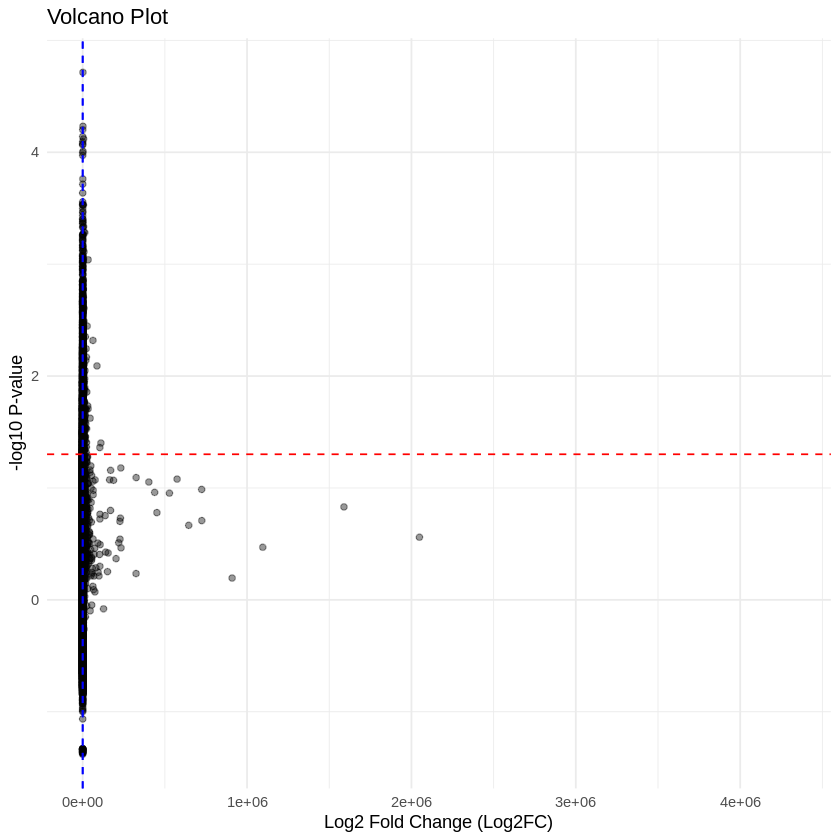

In [136]:
# 1. Rename columns by their position to avoid naming errors
# Based on your previous output, these are usually columns 19 and 20
colnames(DTE_output_table)[19] <- "Log2FC"
colnames(DTE_output_table)[20] <- "PValue"

# 2. Load library
library(ggplot2)

# 3. Create the Volcano Plot using the new simple names
ggplot(DTE_output_table, aes(x = Log2FC, y = -log10(PValue))) +
  geom_point(alpha = 0.4, size = 1.5) +
  theme_minimal() +
  labs(title = "Volcano Plot",
       x = "Log2 Fold Change (Log2FC)",
       y = "-log10 P-value") +
  # Add significance thresholds
  geom_hline(yintercept = -log10(0.05), col = "red", linetype = "dashed") +
  geom_vline(xintercept = c(-1, 1), col = "blue", linetype = "dashed")

<div class="alert alert-block alert-info">
<b>Code Breakdown</b>
<br>

- `gse_pairwise_termsim <- pairwise_termsim(gse)`:  
    - Calculates pairwise _term similarities_ between enriched gene sets from the GSEA results object `gse`.
    - `pairwise_termsim()`:  
        - A function from the `clusterProfiler` package that computes semantic similarities between enriched terms (like GO terms or pathways) based on their shared genes or functional overlap. This helps identify relationships between the enriched terms.
    - `gse`:  
        - The GSEA results object, previously generated using `gseGO()`. This contains the enriched gene sets (e.g., GO terms) and their significance, which is now used to compute pairwise similarities.

- `emapplot(gse_pairwise_termsim, showCategory = 10)`:  
    - Creates an _enrichment map plot_ using the pairwise similarities between enriched terms.
    - `emapplot()`:  
        - A function from the `clusterProfiler` package that generates a network-like visualization (an _enrichment map_) to show relationships between enriched gene sets. Each node represents a gene set (e.g., a GO term), and edges indicate similarity between terms.
    - `gse_pairwise_termsim`:  
        - The object containing pairwise term similarities from the `pairwise_termsim()` function, which is used to create the enrichment map plot.
    - `showCategory = 10`:  
        - Limits the plot to showing the top 10 enriched categories (e.g., GO terms) in the enrichment map. This helps to focus on the most significant terms and their relationships.

</div>

<br>

**Use the Enrichment map plot shown above to answer the following question:**

1. Which biological processes shown have some of the same genes in their gene sets?
   
<br>

<div class="alert alert-block alert-success">

<details>
<summary><b>Q1 Solution</b></summary>

<br>

Biological processes that share common genes in their gene sets are those that are connected by edges in the enrichment map.

</details>
</div>

<br>

---

At the end of every R session, it is good practice to print the session info to record all the packages that were used and their respective versions.

Run the following command to print the session info:

In [137]:
## print session info ##
print(" ")
print("Session Info below: ")
sessionInfo()

[1] " "
[1] "Session Info below: "


R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C               LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8     LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8    LC_PAPER=en_US.UTF-8       LC_NAME=C                  LC_ADDRESS=C               LC_TELEPHONE=C             LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] DOSE_4.6.0                  PANTHER.db_1.0.12           RSQLite_3.52.0              AnnotationHub_4.2.0         BiocFileCache_3.2.0         dbplyr_2.5.2                STRINGdb_2.

## 6. So now what?

Above we performed some of the standard steps to begin to analyze RNAseq data. The list of significantly differentially expressed transcripts and biological processes we identified between group 1 and group 2 can be used as a guide to help generate new hypotheses about the biological impacts of spaceflight. If there are additional contrasts in this dataset you would like to analyze, jump back up to [step 5](#5.-DTE-Data-Visualization) and change the values for `g1` and `g2` to the next two groups you would like to compare and re-run all subsequent analyses.


<a class="anchor" id="copy-to-gd"></a>

## 7. Copy Completed JN to Google Drive
To save a copy of your completed JN to your Google Drive, click on "File" in the top left corner of this JN, then select "Save a copy in Drive" from the drop-down menu.

To access your completed JN and all the files you generated, open the <a href="https://github.com/nasa/GeneLab-Training/blob/GL4U_RNAseq_2024_Colab/On-Demand/Access_anyOSD_transAnnot_JN.md/#access-your-completed-jn-and-output-files">Access_anyOSD_transAnnot_JN</a> instructions in a new tab, and follow the steps in the "Access Your Completed JN and Output Files" section.
> _Note: This is an optional activity, so you do not have to upload this JN to Canvas._
<br>